In [1]:
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.mask import mask
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from typing import Tuple, List, Dict
from tqdm import tqdm
import os
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import zoom
import numpy as np
import numpy as np
import random
import json
from pathlib import Path
from typing import Dict, List, Tuple
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from typing import Dict, Tuple
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from pathlib import Path

from data_loader import (load_dem, load_infiltration_map, load_landuse_map, get_raster_stats, print_raster_stats,visualize_raster, visualize_flood_maps_grid, 
                         load_all_rainfall_scenarios, get_rainfall_stats, load_multiple_map, load_all_flood_maps, visualize_multiple_grid)
from data_preprocessing import (normalize_dem, normalize_infiltration, normalize_landuse, handle_nodata )
from flood_maps import (reconstruct_map_from_patches, categorize_all_flood_maps_patch, visualize_all_categorized_maps)
from training import train_kfold
from testing import (evaluate_test_scenarios, plot_confusion_matrix, plot_flood_on_dem, reconstruct_test_map_from_patches)
from config import Config

RANDOM_SEED = 42
NUM_TRAIN = 15
NUM_TEST = 5
NUM_SCENARIO = 50
PATCH_SIZE = 4

# Hyperparameters
BATCH_SIZE = 64
NUM_WORKERS = 4     
PIN_MEMORY = False 

FLOOD_CLASSES_VEC = {
    0: {
        'name': 'No Flood',
        'range': (0.0, 0.15),
        'color': '#FFFFFF'  # White
    },
    1: {
        'name': 'Light',
        'range': (0.15, 0.24),
        'color': '#C6DBEF'  # Light blue
    },
    2: {
        'name': 'Moderate',
        'range': (0.24, 0.46),
        'color': '#6BAED6'  # Medium blue
    },
    3: {
        'name': 'Heavy',
        'range': (0.46, 0.68),
        'color': '#2171B5'  # Deep blue
    },
    4: {
        'name': 'Extreme',
        'range': (0.68, float('inf')),
        'color': '#08306B'  # Dark navy
    }
}

cfg = Config()

colors = [FLOOD_CLASSES_VEC[i]['color'] for i in range(5)]
cmap = ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = BoundaryNorm(bounds, cmap.N)

In [2]:
repo_root = os.getcwd()
gmm_path = os.path.join(repo_root, "COP-30m-GMM")
manila_path = os.path.join(repo_root, "COP-30m-ManilaOnly")
rs_path = os.path.join(repo_root, "rc_randomized_mm_hr_scenarios")
train_rs_path = os.path.join(rs_path, "train")
test_rs_path = os.path.join(rs_path, "validation")
drainage_path = os.path.join(repo_root, "drainage")
soil_path = os.path.join(repo_root, "soil_types")
building_path = os.path.join(repo_root, "building_info")


# Loading data

In [3]:
# Load DEM
print("\n--- Loading DEM ---")
dem_path = os.path.join(manila_path, "by_box", "manila_bbox_dem_cop.tif")
if os.path.exists(dem_path):
    dem_data, dem_meta = load_dem(dem_path)
    dem_stats = get_raster_stats(dem_data, "DEM")
    print_raster_stats(dem_stats)
else:
    print(f"WARNING: DEM file not found at {dem_path}")
    dem_data = None


--- Loading DEM ---
DEM loaded: shape (320, 320), dtype float32

Statistics for: DEM
Shape:         (320, 320)
Dtype:         float32
Min value:     -9.1316
Max value:     46.7424
Mean value:    6.1565
Std dev:       5.5713
Valid pixels:  102,400 / 102,400



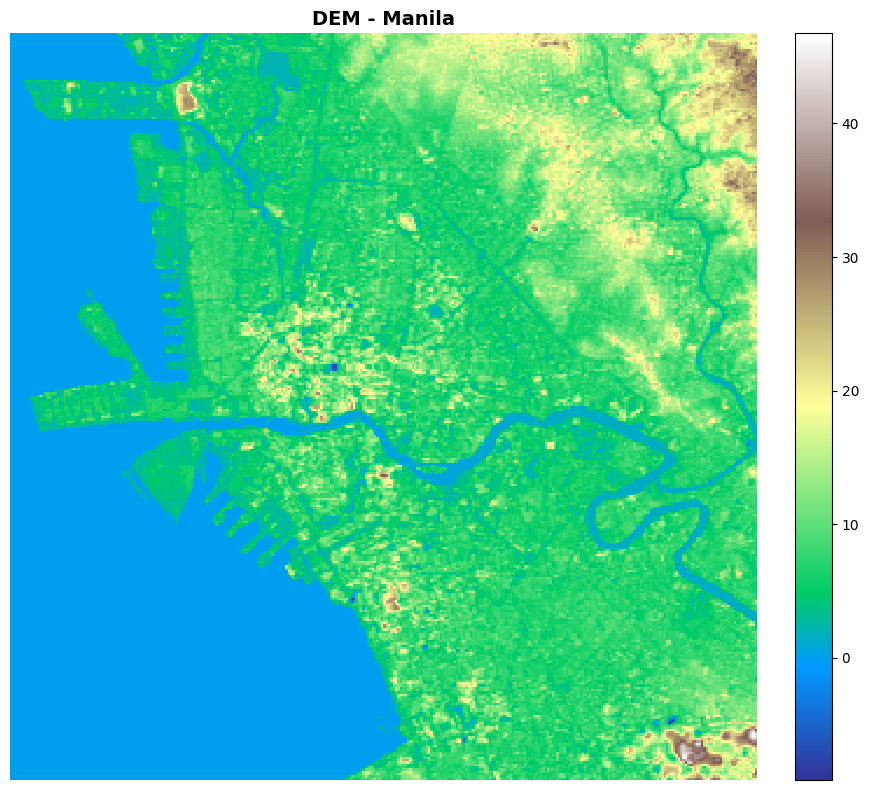

In [4]:
fig1 = visualize_raster(dem_data, title="DEM - Manila", cmap='terrain')

In [5]:
# Load Infiltration Map
print("\n--- Loading Infiltration Map ---")
infilt_path = os.path.join(manila_path, "by_box", "GM_Infilt_Manila_box.tif")
if os.path.exists(infilt_path):
    infilt_data, infilt_meta = load_infiltration_map(infilt_path)
    infilt_stats = get_raster_stats(infilt_data, "Infiltration Map")
    print_raster_stats(infilt_stats)
else:
    print(f"WARNING: Infiltration file not found at {infilt_path}")
    infilt_data = None


--- Loading Infiltration Map ---
Infiltration map loaded: shape (320, 320), dtype float64

Statistics for: Infiltration Map
Shape:         (320, 320)
Dtype:         float64
Min value:     0.0000
Max value:     2.7687
Mean value:    0.0127
Std dev:       0.1795
Valid pixels:  102,400 / 102,400



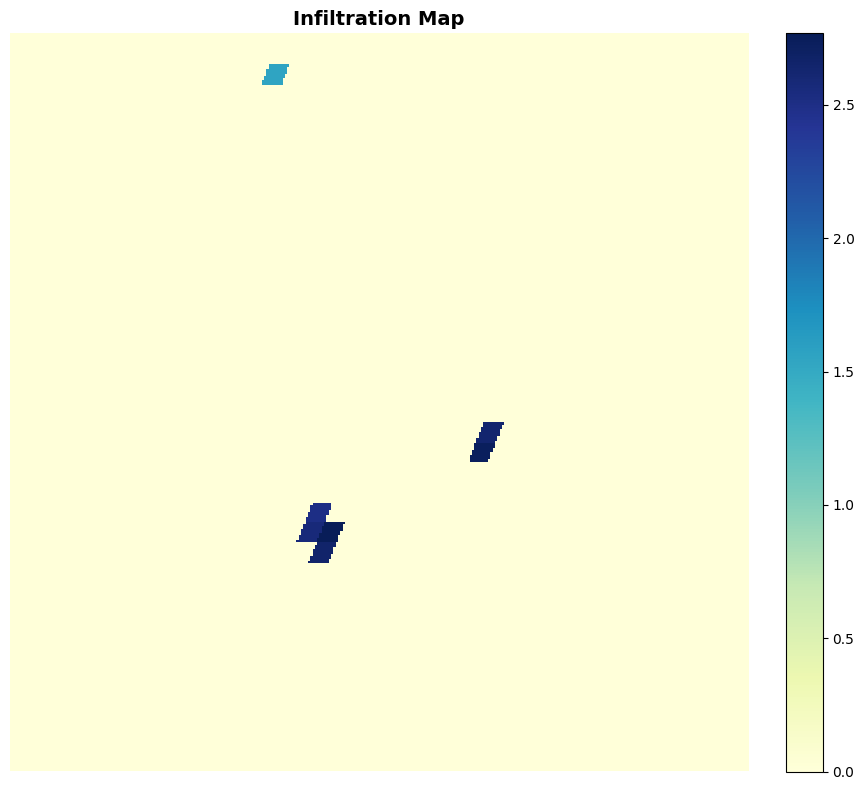

In [6]:
fig2 = visualize_raster(infilt_data, title="Infiltration Map", cmap='YlGnBu')

In [7]:
# Load Landuse Map
print("\n--- Loading Landuse Map ---")
landuse_path = os.path.join(manila_path, "by_box", "GM_LU_Manila_box.tif")
if os.path.exists(landuse_path):
    landuse_data, landuse_meta = load_landuse_map(landuse_path)
    landuse_stats = get_raster_stats(landuse_data, "Landuse Map")
    print_raster_stats(landuse_stats)
else:
    print(f"WARNING: Landuse file not found at {landuse_path}")
    landuse_data = None



--- Loading Landuse Map ---
Landuse map loaded: shape (320, 320), dtype float64

Statistics for: Landuse Map
Shape:         (320, 320)
Dtype:         float64
Min value:     1.0000
Max value:     11.0000
Mean value:    5.7151
Std dev:       1.6457
Valid pixels:  102,400 / 102,400



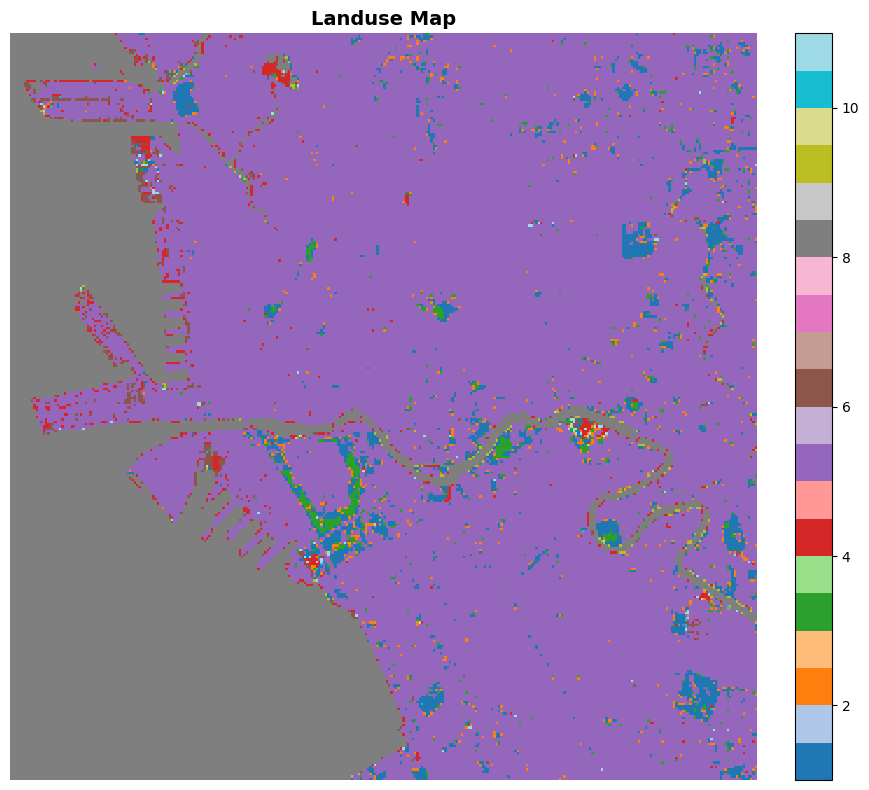

In [8]:
fig3 = visualize_raster(landuse_data, title="Landuse Map", cmap='tab20')

In [9]:
print("\n--- Loading Drainage ---")
drainage_path = os.path.join(drainage_path)

if os.path.exists(drainage_path):
    drainage_data, drainage_meta = load_multiple_map(drainage_path)
    
    # Access individual layers by filename
    for layer_name, layer_data in drainage_data.items():
        print(f"\n  Layer: {layer_name}")
        stats = get_raster_stats(layer_data, layer_name)
        print_raster_stats(stats)
else:
    print(f"WARNING: Drainage folder not found at {drainage_path}")
    drainage_data = None


--- Loading Drainage ---
Found 4 drainage file(s):
  [manila_riverbank_new]: shape (503, 503), dtype float64
  [manila_streams_aligned_new]: shape (503, 503), dtype float64
  [waterway_canals_new]: shape (503, 503), dtype float64
  [waterway_streams_new]: shape (583, 582), dtype float64

  Layer: manila_riverbank_new

Statistics for: manila_riverbank_new
Shape:         (503, 503)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0111
Std dev:       0.1047
Valid pixels:  253,009 / 253,009


  Layer: manila_streams_aligned_new

Statistics for: manila_streams_aligned_new
Shape:         (503, 503)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.1438
Std dev:       0.3509
Valid pixels:  253,009 / 253,009


  Layer: waterway_canals_new

Statistics for: waterway_canals_new
Shape:         (503, 503)
Dtype:         float64
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0006
Std dev:       0.0254
Valid pixels:  

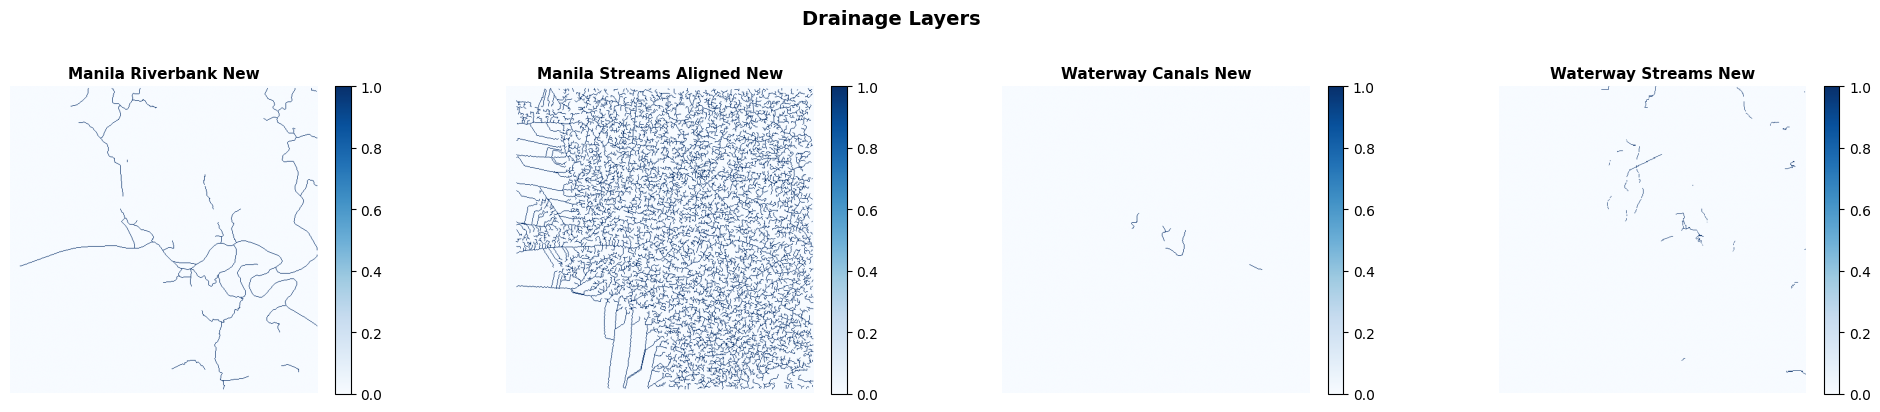

In [10]:
fig = visualize_multiple_grid(data=drainage_data, figsize=(20, 4), cmap='Blues')

In [11]:
print("\n--- Loading Soil Types ---")
soil_types = os.path.join(soil_path)

if os.path.exists(soil_types):
    soil_data, soil_meta = load_multiple_map(soil_types)
    
    for layer_name, layer_data in soil_data.items():
        print(f"\n  Layer: {layer_name}")
        stats = get_raster_stats(layer_data, layer_name)
        print_raster_stats(stats)
else:
    print(f"WARNING: Soil folder not found at {soil_types}")
    soil_data = None


--- Loading Soil Types ---
Found 4 drainage file(s):
  [Clay_Content_Percent_Manila]: shape (37, 37), dtype float64
  [Organic_Carbon_Content_Manila]: shape (37, 37), dtype float64
  [Sand_Content_Percent_Manila]: shape (37, 37), dtype float64
  [Soil_pH_H2O_Manila]: shape (37, 37), dtype float64

  Layer: Clay_Content_Percent_Manila

Statistics for: Clay_Content_Percent_Manila
Shape:         (37, 37)
Dtype:         float64
Min value:     0.0000
Max value:     40.0000
Mean value:    17.5588
Std dev:       16.6425
Valid pixels:  1,369 / 1,369


  Layer: Organic_Carbon_Content_Manila

Statistics for: Organic_Carbon_Content_Manila
Shape:         (37, 37)
Dtype:         float64
Min value:     0.0000
Max value:     36.0000
Mean value:    2.5427
Std dev:       2.9443
Valid pixels:  1,369 / 1,369


  Layer: Sand_Content_Percent_Manila

Statistics for: Sand_Content_Percent_Manila
Shape:         (37, 37)
Dtype:         float64
Min value:     0.0000
Max value:     47.0000
Mean value:    21.3572

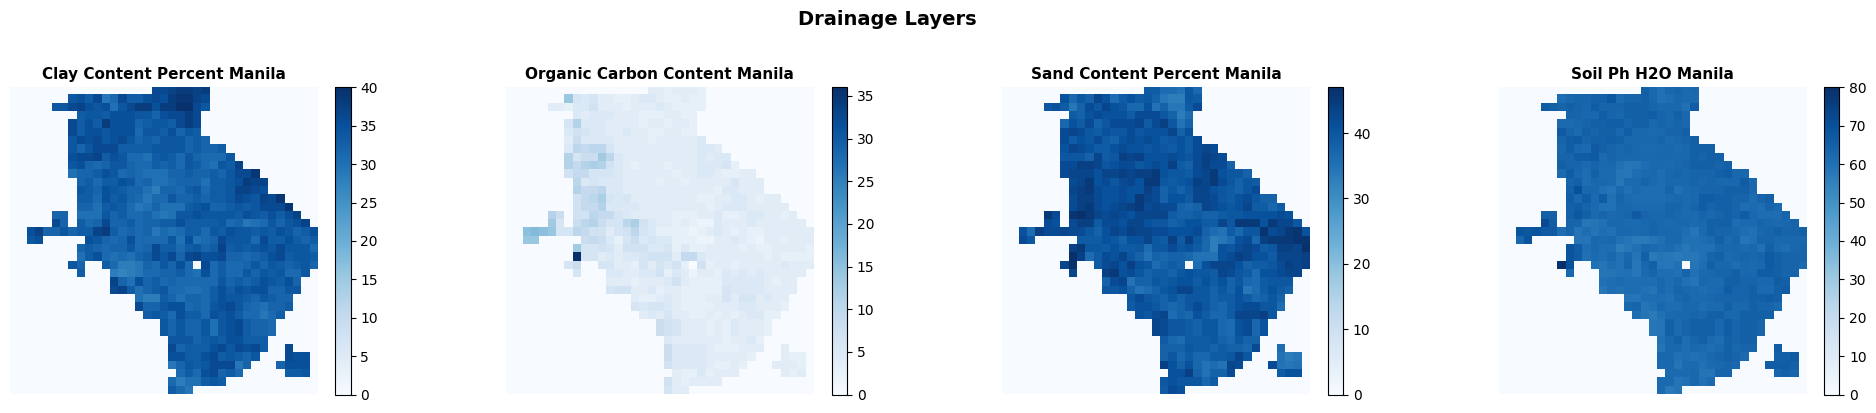

In [12]:
fig = visualize_multiple_grid(data=soil_data, figsize=(20, 4), cmap='Blues')

In [13]:
# Load all flood maps
print("\n--- Loading Flood Maps (Ground Truth) ---")
fm_path = os.path.join(manila_path, "by_box")
flood_maps, flood_metadata = load_all_flood_maps(fm_path, num_scenarios=NUM_SCENARIO)

if len(flood_maps) > 0:
    print(f"\nFlood maps successfully loaded: {len(flood_maps)}")
    
    if len(flood_maps) >= NUM_SCENARIO:
        flood_stats = get_raster_stats(flood_maps[-1], "Flood Map RS20")
else:
    print("WARNING: No flood maps loaded!")


--- Loading Flood Maps (Ground Truth) ---
Flood map RS1 loaded: shape (320, 320), dtype float64
Flood map RS2 loaded: shape (320, 320), dtype float64
Flood map RS3 loaded: shape (320, 320), dtype float64
Flood map RS4 loaded: shape (320, 320), dtype float64
Flood map RS5 loaded: shape (320, 320), dtype float64
Flood map RS6 loaded: shape (320, 320), dtype float64
Flood map RS7 loaded: shape (320, 320), dtype float64
Flood map RS8 loaded: shape (320, 320), dtype float64
Flood map RS9 loaded: shape (320, 320), dtype float64
Flood map RS10 loaded: shape (320, 320), dtype float64
Flood map RS11 loaded: shape (320, 320), dtype float64
Flood map RS12 loaded: shape (320, 320), dtype float64
Flood map RS13 loaded: shape (320, 320), dtype float64
Flood map RS14 loaded: shape (320, 320), dtype float64
Flood map RS15 loaded: shape (320, 320), dtype float64
Flood map RS16 loaded: shape (320, 320), dtype float64
Flood map RS17 loaded: shape (320, 320), dtype float64
Flood map RS18 loaded: shape (3

In [14]:
print_raster_stats(flood_stats)


Statistics for: Flood Map RS20
Shape:         (320, 320)
Dtype:         float64
Min value:     0.0000
Max value:     3.8214
Mean value:    0.1406
Std dev:       0.2650
Valid pixels:  102,400 / 102,400



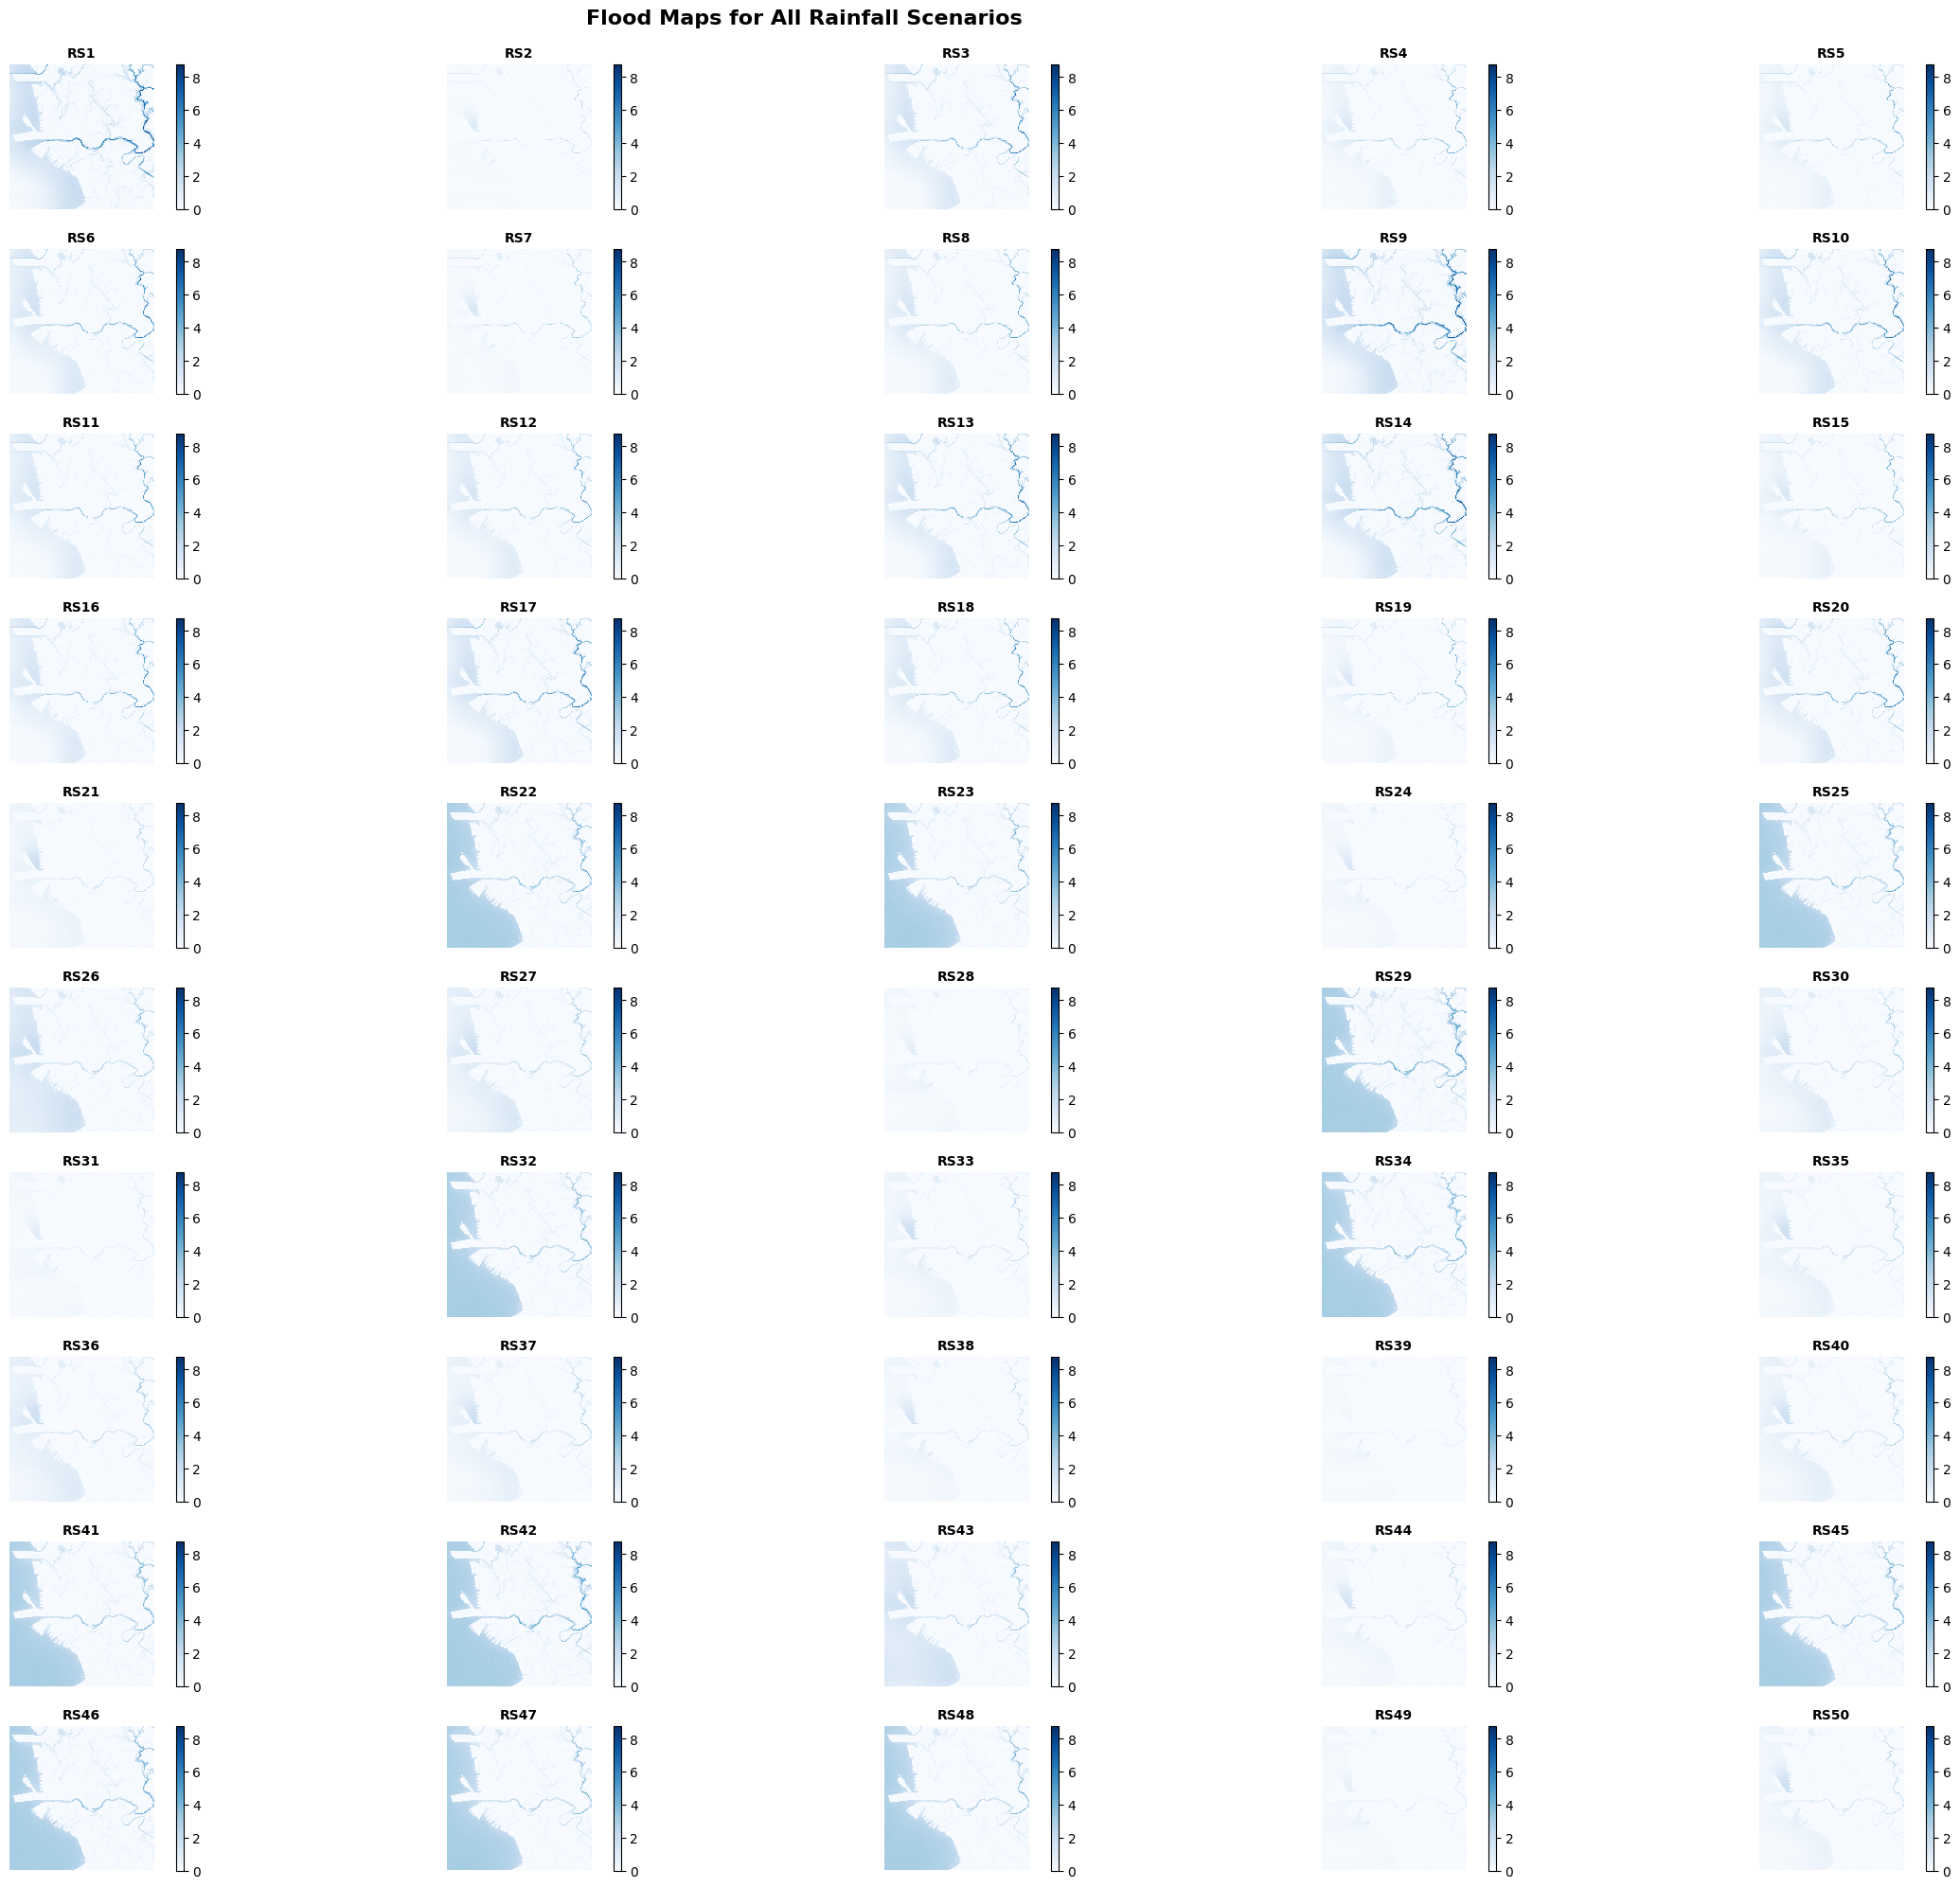

In [15]:
fig4 = visualize_flood_maps_grid(flood_maps=flood_maps,scenario_ids=list(range(1, 51)),figsize=(25, 20),ncols=5,cmap='Blues')
#plt.show()

In [16]:
from RC_randomizer import split_rs_dataset #, split_rs_dataset_three_way

source = "mm_hr_scenarios"
output = "rc_randomized_mm_hr_scenarios"

split_rs_dataset(source_dir=source, output_dir=output)

Rainfall SC 1-10: 7 train | 3 validation
Rainfall SC 11-20: 7 train | 3 validation
Rainfall SC 21-30: 7 train | 3 validation
Rainfall SC 31-50: 14 train | 6 validation

70/30 split completed!


In [17]:
print("LOADING TRAINING RAINFALL SCENARIOS")
# Load rainfall scenarios
train_rainfall_scenarios = load_all_rainfall_scenarios(train_rs_path)

if len(train_rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(train_rainfall_scenarios)}")
    
    if len(train_rainfall_scenarios) >= NUM_SCENARIO:
        rain_stats = get_rainfall_stats(train_rainfall_scenarios[-1], scenario_id=50)
else:
    print("WARNING: No rainfall scenarios loaded!")

LOADING TRAINING RAINFALL SCENARIOS

Rainfall scenarios successfully loaded: 35


In [18]:
print("LOADING VALIDATION RAINFALL SCENARIOS")
# Load rainfall scenarios
test_rainfall_scenarios = load_all_rainfall_scenarios(test_rs_path)

if len(test_rainfall_scenarios) > 0:
    print(f"\nRainfall scenarios successfully loaded: {len(test_rainfall_scenarios)}")
    
    if len(test_rainfall_scenarios) >= NUM_SCENARIO:
        rain_stats = get_rainfall_stats(test_rainfall_scenarios[-1], scenario_id=50)
else:
    print("WARNING: No rainfall scenarios loaded!")

LOADING VALIDATION RAINFALL SCENARIOS

Rainfall scenarios successfully loaded: 15


In [19]:
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Dict, Any

# ── Storm Type Mapping ────────────────────────────────────────────────────────
STORM_TYPE_MAP = {
    1: "front-loaded",
    2: "balanced",
    3: "back-loaded",
    4: "triangular"
}

def parse_pattern_type(pattern_str: str) -> int:
    s = pattern_str.strip().lstrip('\ufeff').lower()
    s = s.replace('\u2011', '-').replace('\u2010', '-').replace('\u2013', '-')
    
    if "back" in s:     
        return 3
    elif "front" in s:
        return 1
    elif "balanced" in s:
        return 2
    elif "triangular" in s or "chicago" in s:
        return 4
    else:
        raise ValueError(f"Unrecognized pattern type string: '{pattern_str}'")

def load_scenario_metadata(info_csv_path: str) -> Dict[int, Dict[str, Any]]:
    """
    Load and parse info.csv into a scenario metadata lookup dict.
    
    Returns
    -------
    dict keyed by scenario_id (int), each value is:
        {
            'type_id'  : int   (1=front-loaded, 2=balanced, 3=back-loaded, 4=triangular)
            'label'    : str
            'depth_mm' : float
            'tpeak'    : float or None  (only for type 4, else None)
        }
    """
    df = pd.read_csv(info_csv_path, encoding='utf-8-sig')
    
    # Normalize column names — strip whitespace
    df.columns = df.columns.str.strip()
    
    metadata = {}
    for _, row in df.iterrows():
        sid     = int(row['No'])
        type_id = parse_pattern_type(str(row['Pattern Type']))
        depth   = float(row['Total storm depth P (mm)'])
        
        raw_tpeak = row['Peak time fraction r (tpeak / D)']
        tpeak = None if (pd.isna(raw_tpeak) or str(raw_tpeak).strip() == '') else float(raw_tpeak)
        
        metadata[sid] = {
            'type_id'  : type_id,
            'label'    : STORM_TYPE_MAP[type_id],
            'depth_mm' : depth,
            'tpeak'    : tpeak,
        }
    
    return metadata


# ── Load ──────────────────────────────────────────────────────────────────────
INFO_CSV_PATH = Path('info.csv')   # adjust if needed
scenario_metadata = load_scenario_metadata(INFO_CSV_PATH)

# Data Preprocessing

## Handle NoData

In [20]:
print("\nProcessing DEM...")
dem_clean = handle_nodata(
    dem_data, 
    nodata_value=dem_meta.get('nodata'),
    fill_method='mean'  # Options: 'mean', 'median', 'zero', 'interpolate'
)
# Verify
# dem_clean_stats = get_raster_stats(dem_clean, "DEM (NoData Handled)")
# print_raster_stats(dem_clean_stats)


Processing DEM...

Handling NoData for Raster...
  NoData pixels: 0 / 102,400 (0.00%)
  ✓ No NoData values found


In [21]:
# 2. Handle NoData in Infiltration
print("\nProcessing Infiltration...")
infilt_clean = handle_nodata(
    infilt_data,
    nodata_value=infilt_meta.get('nodata'),
    fill_method='mean'  # Options: 'mean', 'median', 'zero', 'interpolate'
)

# Verify
# infilt_clean_stats = get_raster_stats(infilt_clean, "Infiltration (NoData Handled)")
# print_raster_stats(infilt_clean_stats)


Processing Infiltration...

Handling NoData for Raster...
  NoData pixels: 0 / 102,400 (0.00%)
  ✓ No NoData values found


In [22]:
# 3. Handle NoData in Landuse
print("\nProcessing Landuse...")
landuse_clean = handle_nodata(
    landuse_data,
    nodata_value=landuse_meta.get('nodata'),
    fill_method='interpolate'  # Interpolate is better for categorical data
)

# Verify
# landuse_clean_stats = get_raster_stats(landuse_clean, "Landuse (NoData Handled)")
# print_raster_stats(landuse_clean_stats)


Processing Landuse...

Handling NoData for Raster...
  NoData pixels: 0 / 102,400 (0.00%)
  ✓ No NoData values found


In [23]:
# 4. Handle NoData in Drainage
drainage_clean = {}
for layer_name, layer_data in drainage_data.items():
    drainage_clean[layer_name] = handle_nodata(
        layer_data,
        fill_method='mean',
        name=layer_name
    )



Handling NoData for manila_riverbank_new...
  NoData pixels: 0 / 253,009 (0.00%)
  ✓ No NoData values found

Handling NoData for manila_streams_aligned_new...
  NoData pixels: 0 / 253,009 (0.00%)
  ✓ No NoData values found

Handling NoData for waterway_canals_new...
  NoData pixels: 0 / 253,009 (0.00%)
  ✓ No NoData values found

Handling NoData for waterway_streams_new...
  NoData pixels: 0 / 339,306 (0.00%)
  ✓ No NoData values found


In [24]:
# 5. Handle NoData in Soil Types
soil_clean = {}
for layer_name, layer_data in soil_data.items():
    soil_clean[layer_name] = handle_nodata(
        layer_data,
        fill_method='mean',
        name=layer_name
    )



Handling NoData for Clay_Content_Percent_Manila...
  NoData pixels: 0 / 1,369 (0.00%)
  ✓ No NoData values found

Handling NoData for Organic_Carbon_Content_Manila...
  NoData pixels: 0 / 1,369 (0.00%)
  ✓ No NoData values found

Handling NoData for Sand_Content_Percent_Manila...
  NoData pixels: 0 / 1,369 (0.00%)
  ✓ No NoData values found

Handling NoData for Soil_pH_H2O_Manila...
  NoData pixels: 0 / 1,369 (0.00%)
  ✓ No NoData values found


## Normalization

In [25]:
# Normalize DEM
print("\nNormalizing DEM...")
dem_normalized, dem_params = normalize_dem(dem_clean, method='minmax')

print("\nReshaping DEM to 320×320...")
print(f"  Original shape: {dem_normalized.shape}")
zoom_factor_h = 320 / dem_normalized.shape[0] 
zoom_factor_w = 320 / dem_normalized.shape[1]  

# Resize using zoom
dem_normalized = zoom(dem_normalized, (zoom_factor_h, zoom_factor_w), order=1)  # order=1 for bilinear

print(f"  New shape: {dem_normalized.shape}")
print(f"  Value range: [{dem_normalized.min():.4f}, {dem_normalized.max():.4f}]")

dem_normalized, dem_params = normalize_dem(dem_normalized, method='minmax')
# Verify normalization
dem_norm_stats = get_raster_stats(dem_normalized, "DEM (Normalized)")
print_raster_stats(dem_norm_stats)


Normalizing DEM...
DEM normalized (min-max): [-9.1316, 46.7424] -> [0.0, 1.0]

Reshaping DEM to 320×320...
  Original shape: (320, 320)
  New shape: (320, 320)
  Value range: [0.0000, 1.0000]
DEM normalized (min-max): [0.0000, 1.0000] -> [0.0, 1.0]

Statistics for: DEM (Normalized)
Shape:         (320, 320)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.2736
Std dev:       0.0997
Valid pixels:  102,400 / 102,400



In [26]:
# Normalize Infiltration
print("\nNormalizing Infiltration...")
infilt_normalized, infilt_params = normalize_infiltration(infilt_clean)
# Verify normalization
infilt_norm_stats = get_raster_stats(infilt_normalized, "Infiltration (Normalized)")
print_raster_stats(infilt_norm_stats)


Normalizing Infiltration...
Infiltration normalized (min-max): [0.0000, 2.7687] -> [0.0, 1.0]

Statistics for: Infiltration (Normalized)
Shape:         (320, 320)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.0046
Std dev:       0.0648
Valid pixels:  102,400 / 102,400



In [27]:
# Normalize Landuse
print("\nNormalizing Landuse...")
landuse_normalized, landuse_params = normalize_landuse(landuse_clean, method='minmax')
# Verify normalization
landuse_norm_stats = get_raster_stats(landuse_normalized, "Landuse (Normalized)")
print_raster_stats(landuse_norm_stats)


Normalizing Landuse...
Landuse normalized (min-max): [1.0000, 11.0000] -> [0.0, 1.0]

Statistics for: Landuse (Normalized)
Shape:         (320, 320)
Dtype:         float32
Min value:     0.0000
Max value:     1.0000
Mean value:    0.4715
Std dev:       0.1646
Valid pixels:  102,400 / 102,400



In [28]:
# Normalize Drainage
drainage_norm = {}
for layer_name, layer_data in drainage_clean.items():
    # Drainage layers are already binary (0/1), just confirm range
    vmin, vmax = layer_data.min(), layer_data.max()
    if vmin == 0.0 and vmax == 1.0:
        # Already in [0, 1] — no normalization needed
        drainage_norm[layer_name] = layer_data.copy()
        print(f"  {layer_name}: Already [0, 1] ✓ (binary mask)")

  manila_riverbank_new: Already [0, 1] ✓ (binary mask)
  manila_streams_aligned_new: Already [0, 1] ✓ (binary mask)
  waterway_canals_new: Already [0, 1] ✓ (binary mask)
  waterway_streams_new: Already [0, 1] ✓ (binary mask)


In [29]:
# Normalize Soil Types
soil_norm = {}
soil_norm_params = {}

for layer_name, layer_data in soil_clean.items():
    norm_data, params = normalize_dem(layer_data, method='minmax')  # reuse 
    soil_norm[layer_name] = norm_data
    soil_norm_params[layer_name] = params
    print(f"  {layer_name}: [{params['min']:.4f}, {params['max']:.4f}] → [0, 1] ✓")


DEM normalized (min-max): [0.0000, 40.0000] -> [0.0, 1.0]
  Clay_Content_Percent_Manila: [0.0000, 40.0000] → [0, 1] ✓
DEM normalized (min-max): [0.0000, 36.0000] -> [0.0, 1.0]
  Organic_Carbon_Content_Manila: [0.0000, 36.0000] → [0, 1] ✓
DEM normalized (min-max): [0.0000, 47.0000] -> [0.0, 1.0]
  Sand_Content_Percent_Manila: [0.0000, 47.0000] → [0, 1] ✓
DEM normalized (min-max): [0.0000, 80.0000] -> [0.0, 1.0]
  Soil_pH_H2O_Manila: [0.0000, 80.0000] → [0, 1] ✓


In [30]:
# Resize Drainage
TARGET_SHAPE = (320, 320)

drainage_resized = {}
for layer_name, layer_data in drainage_norm.items():
    zoom_h = TARGET_SHAPE[0] / layer_data.shape[0]
    zoom_w = TARGET_SHAPE[1] / layer_data.shape[1]
    resized = zoom(layer_data, (zoom_h, zoom_w), order=1)
    drainage_resized[layer_name] = resized
    print(f"  {layer_name}: {layer_data.shape} → {resized.shape} ✓")

  manila_riverbank_new: (503, 503) → (320, 320) ✓
  manila_streams_aligned_new: (503, 503) → (320, 320) ✓
  waterway_canals_new: (503, 503) → (320, 320) ✓
  waterway_streams_new: (583, 582) → (320, 320) ✓


In [31]:
# Resize Drainage
soil_resized = {}
for layer_name, layer_data in soil_norm.items():
    zoom_h = TARGET_SHAPE[0] / layer_data.shape[0]
    zoom_w = TARGET_SHAPE[1] / layer_data.shape[1]
    resized = zoom(layer_data, (zoom_h, zoom_w), order=1)
    soil_resized[layer_name] = resized
    print(f"  {layer_name}: {layer_data.shape} → {resized.shape} ✓")

  Clay_Content_Percent_Manila: (37, 37) → (320, 320) ✓
  Organic_Carbon_Content_Manila: (37, 37) → (320, 320) ✓
  Sand_Content_Percent_Manila: (37, 37) → (320, 320) ✓
  Soil_pH_H2O_Manila: (37, 37) → (320, 320) ✓


# Flood Maps (Ground Truths)

In [32]:
print("\nFlood Susceptibility Class Definitions:")
for class_id, info in FLOOD_CLASSES_VEC.items():
    min_val, max_val = info['range']
    max_str = f"{max_val:.2f}" if max_val != float('inf') else "∞"
    print(f"  Class {class_id}: {info['name']:12s} - Range: [{min_val:.2f}, {max_str}) meters")



Flood Susceptibility Class Definitions:
  Class 0: No Flood     - Range: [0.00, 0.15) meters
  Class 1: Light        - Range: [0.15, 0.24) meters
  Class 2: Moderate     - Range: [0.24, 0.46) meters
  Class 3: Heavy        - Range: [0.46, 0.68) meters
  Class 4: Extreme      - Range: [0.68, ∞) meters


In [33]:
flood_maps_categorized_patch, patch_metadata = categorize_all_flood_maps_patch(
    flood_maps, 
    patch_size=PATCH_SIZE, 
    FLOOD_CLASSES=FLOOD_CLASSES_VEC,
    verbose=True
)


PATCH-BASED FLOOD MAP CATEGORIZATION

Configuration:
  Patch size: 4×4
  Stride: 4 (non-overlapping)
  Categorization method: majority

Class definitions:
  Class 0: No Flood     [0.00, 0.15) m
  Class 1: Light        [0.15, 0.24) m
  Class 2: Moderate     [0.24, 0.46) m
  Class 3: Heavy        [0.46, 0.68) m
  Class 4: Extreme      [0.68, ∞) m

Scenario  1 (6400 patches):
  No Flood    :  3,819 patches (59.67%)
  Light       :    190 patches ( 2.97%)
  Moderate    :    325 patches ( 5.08%)
  Heavy       :    195 patches ( 3.05%)
  Extreme     :  1,871 patches (29.23%)
Scenario  2 (6400 patches):
  No Flood    :  6,208 patches (97.00%)
  Light       :     48 patches ( 0.75%)
  Moderate    :     67 patches ( 1.05%)
  Heavy       :     26 patches ( 0.41%)
  Extreme     :     51 patches ( 0.80%)
Scenario  3 (6400 patches):
  No Flood    :  4,577 patches (71.52%)
  Light       :    118 patches ( 1.84%)
  Moderate    :    264 patches ( 4.12%)
  Heavy       :    286 patches ( 4.47%)
  Extre

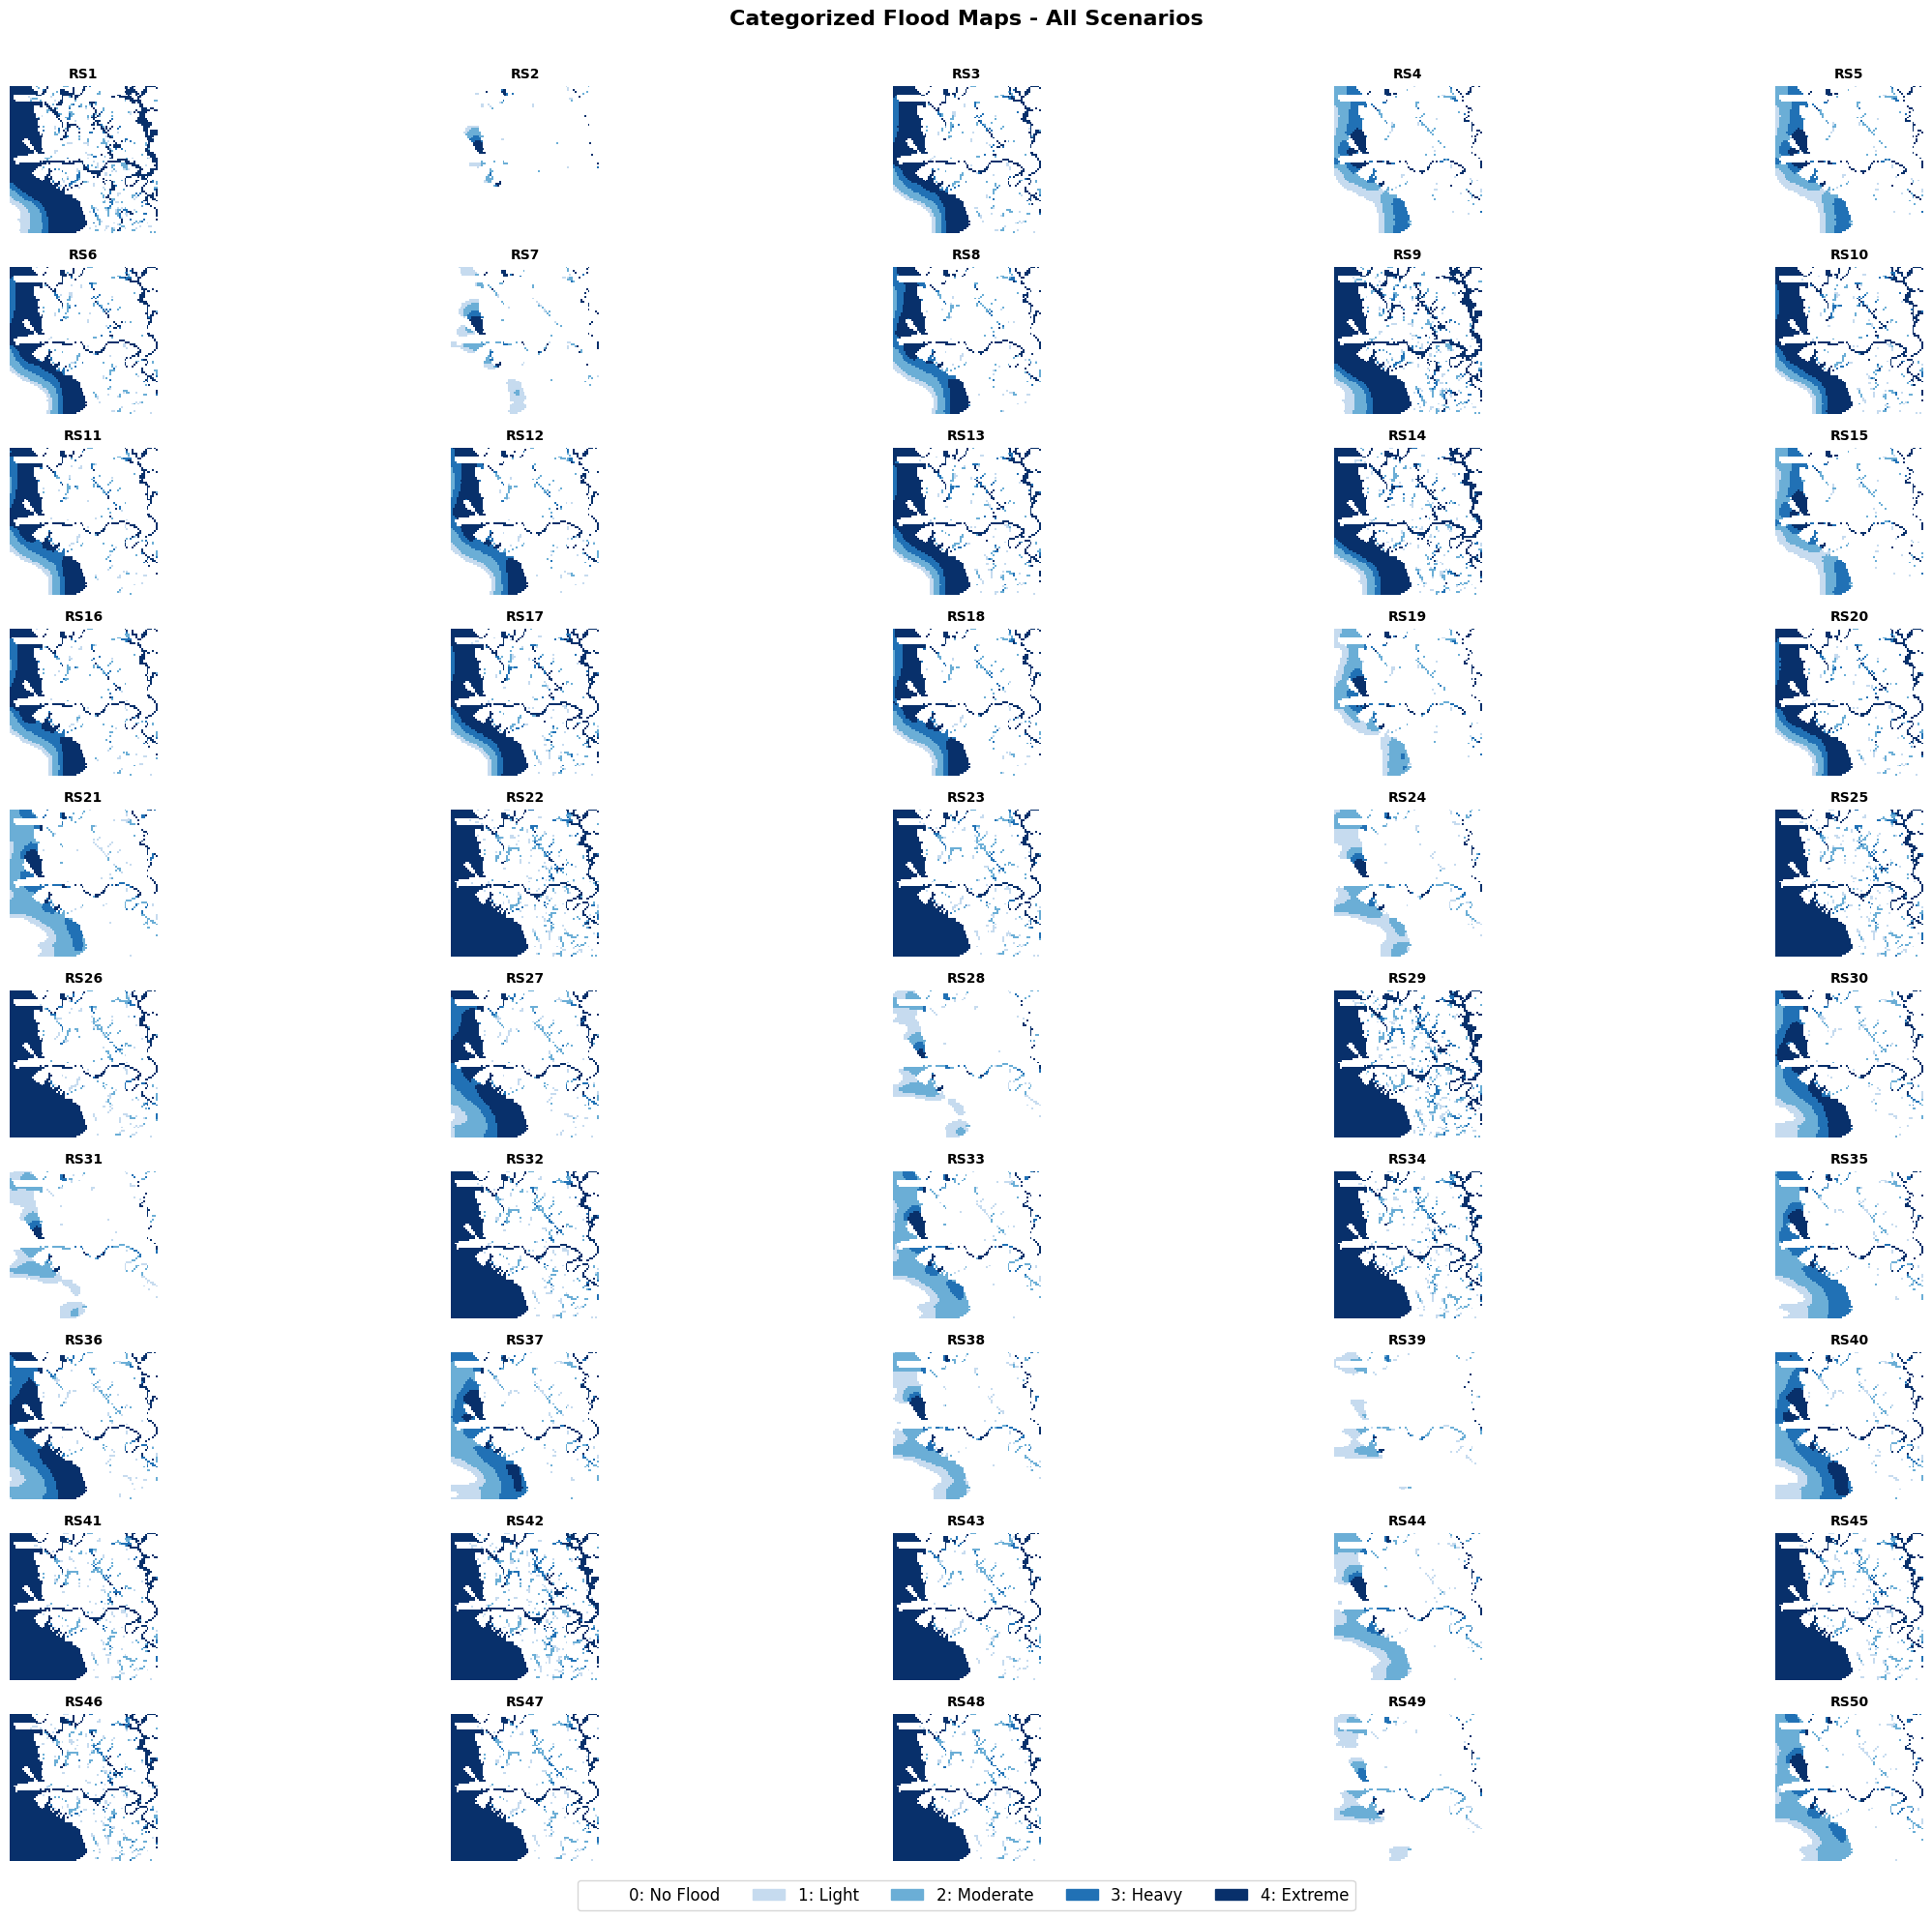

In [34]:
reconstructed_maps = []
for patch_labels, metadata in zip(flood_maps_categorized_patch, patch_metadata):
    reconstructed = reconstruct_map_from_patches(patch_labels, metadata, method='nearest')
    reconstructed_maps.append(reconstructed)

fig_all = visualize_all_categorized_maps(
    reconstructed_maps, 
    FLOOD_CLASSES=FLOOD_CLASSES_VEC,
    scenario_ids=list(range(1, 51))
)

plt.show()

In [35]:
display(flood_maps_categorized_patch)
# display(patch_metadata)

[array([4, 4, 4, ..., 0, 2, 0], dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], dtype=int8),
 array([2, 2, 2, ..., 0, 0, 0], dtype=int8),
 array([2, 2, 2, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], dtype=int8),
 array([0, 0, 0, ..., 0, 0, 0], dtype=int8),
 array([3, 3, 4, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 4, ..., 0, 2, 0], dtype=int8),
 array([4, 4, 4, ..., 0, 1, 0], dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], dtype=int8),
 array([3, 4, 4, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], dtype=int8),
 array([2, 2, 2, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], dtype=int8),
 array([3, 4, 4, ..., 0, 0, 0], dtype=int8),
 array([1, 1, 1, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 4, ..., 0, 0, 0], dtype=int8),
 array([2, 2, 2, ..., 0, 0, 0], dtype=int8),
 array([4, 4, 4, ..., 0, 2, 0], dtype=int8),
 array([4,

# Data Splitting Strategy

In [36]:
print("\nScenario Split")
print("-" * 70)

import os
import re

def get_scenario_ids_from_dir(folder_path: str) -> List[int]:
    ids = []
    for fname in os.listdir(folder_path):
        if not os.path.isfile(os.path.join(folder_path, fname)):
            continue
        match = re.search(r'Scenario_(\d+)_mmhr', fname)
        if match:
            ids.append(int(match.group(1)))
    return sorted(ids)

train_scenario_ids = get_scenario_ids_from_dir(train_rs_path)
test_scenario_ids  = get_scenario_ids_from_dir(test_rs_path)

NUM_TRAIN = len(train_scenario_ids)
NUM_TEST  = len(test_scenario_ids)

print(f"Total scenarios : {NUM_TRAIN + NUM_TEST}")
print(f"Train scenarios : {NUM_TRAIN}")
print(f"Test  scenarios : {NUM_TEST}")

train_rs_lookup = {sid: df for sid, df in zip(train_scenario_ids, train_rainfall_scenarios)}
test_rs_lookup  = {sid: df for sid, df in zip(test_scenario_ids,  test_rainfall_scenarios)}

def extract_rainfall_sequence(rainfall_df) -> np.ndarray:
    if 'intensity_mmhr' in rainfall_df.columns:
        return rainfall_df['intensity_mmhr'].values.astype(np.float32)
    raise ValueError("Column 'intensity_mmhr' not found in rainfall DataFrame.")


# ── Rainfall Normalization ───────────────────
raw_train_sequences = [extract_rainfall_sequence(train_rs_lookup[sid]) for sid in train_scenario_ids]
all_train_intensities = np.concatenate(raw_train_sequences)
rain_min = float(all_train_intensities.min())
rain_max = float(all_train_intensities.max())

print(f"\nRainfall Normalization (train statistics only):")
print(f"  rain_min : {rain_min:.4f} mm/hr")
print(f"  rain_max : {rain_max:.4f} mm/hr")

def normalize_sequence(seq: np.ndarray, rain_min: float, rain_max: float) -> np.ndarray:
    return ((seq - rain_min) / (rain_max - rain_min + 1e-8)).astype(np.float32)




Scenario Split
----------------------------------------------------------------------
Total scenarios : 50
Train scenarios : 35
Test  scenarios : 15

Rainfall Normalization (train statistics only):
  rain_min : 0.0000 mm/hr
  rain_max : 189.8531 mm/hr


# Hyetographs

In [37]:
# ── Build tpeak and depth_norm arrays ────────────────────────────────────────
print("\nBuilding tpeak and depth_norm conditioning arrays")
print("-" * 70)

# ── depth normalization stats from TRAIN only ─────────────────────────────────
train_depths = np.array([scenario_metadata[sid]['depth_mm'] for sid in train_scenario_ids],
                         dtype=np.float32)
depth_min = float(train_depths.min())
depth_max = float(train_depths.max())

print(f"  depth_min (train) : {depth_min:.2f} mm")
print(f"  depth_max (train) : {depth_max:.2f} mm")

# ── builder function ──────────────────────────────────────────────────────────
def build_storm_param_arrays(scenario_ids, scenario_metadata, depth_min, depth_max):
    tpeak_arr      = np.zeros(len(scenario_ids), dtype=np.float32)
    depth_norm_arr = np.zeros(len(scenario_ids), dtype=np.float32)

    for i, sid in enumerate(scenario_ids):
        meta = scenario_metadata[sid]

        # tpeak — only triangular storms have it, others get 0.0
        tpeak_arr[i] = float(meta['tpeak']) if meta['tpeak'] is not None else 0.0

        # depth_norm — normalize using train-set min/max
        depth_norm_arr[i] = (meta['depth_mm'] - depth_min) / (depth_max - depth_min + 1e-8)

    return tpeak_arr, depth_norm_arr

# ── build for train and test ──────────────────────────────────────────────────
train_tpeak_arr, train_depth_norm_arr = build_storm_param_arrays(
    train_scenario_ids, scenario_metadata, depth_min, depth_max
)
test_tpeak_arr, test_depth_norm_arr = build_storm_param_arrays(
    test_scenario_ids, scenario_metadata, depth_min, depth_max
)

# ── verification printout ─────────────────────────────────────────────────────
print(f"\n  TRAIN ({len(train_scenario_ids)} scenarios):")
print(f"  {'SID':<6} {'Type':<15} {'depth_mm':>9} {'depth_norm':>11} {'tpeak':>7}")
print(f"  {'-'*52}")
for i, sid in enumerate(train_scenario_ids):
    meta = scenario_metadata[sid]
    print(f"  {sid:<6} {meta['label']:<15} {meta['depth_mm']:>9.2f} "
          f"{train_depth_norm_arr[i]:>11.4f} {train_tpeak_arr[i]:>7.2f}")

print(f"\n  TEST ({len(test_scenario_ids)} scenarios):")
print(f"  {'SID':<6} {'Type':<15} {'depth_mm':>9} {'depth_norm':>11} {'tpeak':>7}")
print(f"  {'-'*52}")
for i, sid in enumerate(test_scenario_ids):
    meta = scenario_metadata[sid]
    print(f"  {sid:<6} {meta['label']:<15} {meta['depth_mm']:>9.2f} "
          f"{test_depth_norm_arr[i]:>11.4f} {test_tpeak_arr[i]:>7.2f}")

print(f"\n  tpeak range  (train): [{train_tpeak_arr.min():.2f}, {train_tpeak_arr.max():.2f}]")
print(f"  tpeak range  (test) : [{test_tpeak_arr.min():.2f}, {test_tpeak_arr.max():.2f}]")
print(f"  depth_norm   (train): [{train_depth_norm_arr.min():.4f}, {train_depth_norm_arr.max():.4f}]")
print(f"  depth_norm   (test) : [{test_depth_norm_arr.min():.4f}, {test_depth_norm_arr.max():.4f}]")
print(f"\n  ✓ train_tpeak_arr      shape: {train_tpeak_arr.shape}")
print(f"  ✓ train_depth_norm_arr shape: {train_depth_norm_arr.shape}")
print(f"  ✓ test_tpeak_arr       shape: {test_tpeak_arr.shape}")
print(f"  ✓ test_depth_norm_arr  shape: {test_depth_norm_arr.shape}")


Building tpeak and depth_norm conditioning arrays
----------------------------------------------------------------------
  depth_min (train) : 6.00 mm
  depth_max (train) : 78.00 mm

  TRAIN (35 scenarios):
  SID    Type             depth_mm  depth_norm   tpeak
  ----------------------------------------------------
  2      front-loaded         6.00      0.0000    0.00
  3      front-loaded        34.00      0.3889    0.00
  5      front-loaded        17.00      0.1528    0.00
  6      front-loaded        33.00      0.3750    0.00
  7      front-loaded        11.00      0.0694    0.00
  8      front-loaded        21.00      0.2083    0.00
  9      front-loaded        78.00      1.0000    0.00
  12     balanced            28.00      0.3056    0.00
  13     balanced            53.00      0.6528    0.00
  14     balanced            78.00      1.0000    0.00
  15     balanced            22.00      0.2222    0.00
  16     balanced            37.00      0.4306    0.00
  18     balanced     

In [38]:
# ── Storm Type One-Hot Encoding ───────────────────────────────────────────────
NUM_STORM_TYPES = 4

def get_storm_type_onehot(sid: int, scenario_metadata: Dict) -> np.ndarray:
    """Return a (4,) one-hot vector for the storm type of scenario sid."""
    type_id = scenario_metadata[sid]['type_id']        # 1-indexed (1,2,3,4)
    onehot  = np.zeros(NUM_STORM_TYPES, dtype=np.float32)
    onehot[type_id - 1] = 1.0
    return onehot

# Quick sanity check
print(f"\nStorm Type One-Hot Examples:")
for sid in [2, 12, 21, 31]:
    oh = get_storm_type_onehot(sid, scenario_metadata)
    print(f"  Scenario {sid:>2} ({scenario_metadata[sid]['label']:<15}): {oh}")


Storm Type One-Hot Examples:
  Scenario  2 (front-loaded   ): [1. 0. 0. 0.]
  Scenario 12 (balanced       ): [0. 1. 0. 0.]
  Scenario 21 (back-loaded    ): [0. 0. 1. 0.]
  Scenario 31 (triangular     ): [0. 0. 0. 1.]


In [39]:
def validate_and_print_metadata(
    scenario_metadata : Dict[int, Dict[str, Any]],
    train_scenario_ids: list,
    test_scenario_ids : list,
) -> None:

    all_ids = sorted(scenario_metadata.keys())
    all_loaded = train_scenario_ids + test_scenario_ids

    print("\nSCENARIO METADATA LOADED")
    print("-" * 70)
    print(f"Total scenarios in info.csv : {len(all_ids)}")

    # ── Overall type distribution ─────────────────────────────────────────────
    print("\nStorm type distribution (full dataset):")
    for tid, tlabel in STORM_TYPE_MAP.items():
        ids_of_type = [sid for sid, m in scenario_metadata.items() if m['type_id'] == tid]
        print(f"  Type {tid} - {tlabel:<15}: {len(ids_of_type):>2} scenarios  "
              f"(IDs: {min(ids_of_type)}–{max(ids_of_type)})")

    # ── Train split breakdown ─────────────────────────────────────────────────
    print("\nTrain set type distribution:")
    for tid, tlabel in STORM_TYPE_MAP.items():
        count = sum(1 for sid in train_scenario_ids if scenario_metadata[sid]['type_id'] == tid)
        ids   = [sid for sid in train_scenario_ids if scenario_metadata[sid]['type_id'] == tid]
        print(f"  Type {tid} - {tlabel:<15}: {count:>2} scenarios  (IDs: {ids})")

    # ── Test split breakdown ──────────────────────────────────────────────────
    print("\nTest set type distribution:")
    for tid, tlabel in STORM_TYPE_MAP.items():
        count = sum(1 for sid in test_scenario_ids if scenario_metadata[sid]['type_id'] == tid)
        ids   = [sid for sid in test_scenario_ids if scenario_metadata[sid]['type_id'] == tid]
        print(f"  Type {tid} - {tlabel:<15}: {count:>2} scenarios  (IDs: {ids})")

    # ── Triangular tpeak summary ──────────────────────────────────────────────
    tri_ids = [sid for sid, m in scenario_metadata.items() if m['type_id'] == 4]
    tpeaks  = [scenario_metadata[sid]['tpeak'] for sid in tri_ids]
    print(f"\nTriangular storm tpeak range : {min(tpeaks):.2f} – {max(tpeaks):.2f}")

    # ── Validation check ──────────────────────────────────────────────────────
    print("\nMetadata validation:")
    missing = [sid for sid in all_loaded if sid not in scenario_metadata]
    extra   = [sid for sid in all_ids    if sid not in all_loaded]

    if not missing:
        print(f"  All {len(all_loaded)} loaded scenario IDs found in metadata ✓")
    else:
        print(f"  WARNING: {len(missing)} scenario IDs missing from metadata: {missing}")

    if extra:
        print(f"  NOTE: {len(extra)} metadata IDs not in train/test split: {extra}")
    else:
        print(f"  All metadata IDs accounted for in train/test split ✓")

# ── Run validation ────────────────────────────────────────────────────────────
validate_and_print_metadata(scenario_metadata, train_scenario_ids, test_scenario_ids)


SCENARIO METADATA LOADED
----------------------------------------------------------------------
Total scenarios in info.csv : 50

Storm type distribution (full dataset):
  Type 1 - front-loaded   : 10 scenarios  (IDs: 1–10)
  Type 2 - balanced       : 10 scenarios  (IDs: 11–20)
  Type 3 - back-loaded    : 10 scenarios  (IDs: 21–30)
  Type 4 - triangular     : 20 scenarios  (IDs: 31–50)

Train set type distribution:
  Type 1 - front-loaded   :  7 scenarios  (IDs: [2, 3, 5, 6, 7, 8, 9])
  Type 2 - balanced       :  7 scenarios  (IDs: [12, 13, 14, 15, 16, 18, 19])
  Type 3 - back-loaded    :  7 scenarios  (IDs: [21, 22, 23, 25, 26, 28, 30])
  Type 4 - triangular     : 14 scenarios  (IDs: [31, 32, 33, 34, 36, 38, 40, 42, 45, 46, 47, 48, 49, 50])

Test set type distribution:
  Type 1 - front-loaded   :  3 scenarios  (IDs: [1, 4, 10])
  Type 2 - balanced       :  3 scenarios  (IDs: [11, 17, 20])
  Type 3 - back-loaded    :  3 scenarios  (IDs: [24, 27, 29])
  Type 4 - triangular     :  6 sce

In [40]:
from hyetograph import verify_against_csv
#   Type 1 - front-loaded   :  3 scenarios  (IDs: [1, 4, 10])
# Scenario 1 — front-loaded, 38mm
raw_csv_seq_1 = extract_rainfall_sequence(test_rs_lookup[1])
verify_against_csv(
    storm_type   = 'front-loaded',
    depth_mm     = 38,
    csv_sequence = raw_csv_seq_1,
    tolerance    = 0.5
)

raw_csv_seq_4 = extract_rainfall_sequence(test_rs_lookup[4])
verify_against_csv(
    storm_type   = 'front-loaded',
    depth_mm     = 54,
    csv_sequence = raw_csv_seq_4,
    tolerance    = 0.5
)

raw_csv_seq_10 = extract_rainfall_sequence(test_rs_lookup[10])
verify_against_csv(
    storm_type   = 'front-loaded',
    depth_mm     = 41,
    csv_sequence = raw_csv_seq_10,
    tolerance    = 0.5
)

verify_against_csv(
    storm_type   = 'front-loaded',
    depth_mm     = 6,
    csv_sequence = extract_rainfall_sequence(train_rs_lookup[2]),
    tolerance    = 0.5
)


Verification — front-loaded, 38mm
Step      Generated          CSV       Diff   Status
------------------------------------------------------
1           39.7222      39.7222     0.0000        ✓
2           82.8172      82.8172     0.0000        ✓
3           92.4925      92.4925     0.0000        ✓
4           82.9881      82.9881     0.0000        ✓
5           64.6740      64.6740     0.0000        ✓
6           44.5952      44.5952     0.0000        ✓
7           27.0170      27.0170     0.0000        ✓
8           13.9696      13.9696     0.0000        ✓
9            5.7938       5.7938     0.0000        ✓
10           1.6856       1.6856     0.0000        ✓
11           0.2414       0.2414     0.0000        ✓
12           0.0033       0.0033     0.0000        ✓
13           0.0000       0.0000     0.0000        ✓
------------------------------------------------------
Max diff : 0.0000 mm/hr
Result   : ALL PASS ✓

Verification — front-loaded, 54mm
Step      Generated          CSV

In [41]:
# Type 2 - balanced       :  3 scenarios  (IDs: [11, 17, 20])
# Scenario 11 — balanced, 35mm
verify_against_csv('balanced', 35, extract_rainfall_sequence(test_rs_lookup[11]), tolerance=0.01)
verify_against_csv('balanced', 54, extract_rainfall_sequence(test_rs_lookup[17]), tolerance=0.01)
verify_against_csv('balanced', 47, extract_rainfall_sequence(test_rs_lookup[20]), tolerance=0.01)
verify_against_csv('balanced', 37, extract_rainfall_sequence(train_rs_lookup[16]), tolerance=0.01)



Verification — balanced, 35mm
Step      Generated          CSV       Diff   Status
------------------------------------------------------
1            3.7893       3.7893     0.0000        ✓
2           17.1781      17.1781     0.0000        ✓
3           31.8089      31.8089     0.0000        ✓
4           44.5947      44.5947     0.0000        ✓
5           53.8845      53.8845     0.0000        ✓
6           58.7445      58.7445     0.0000        ✓
7           58.7445      58.7445     0.0000        ✓
8           53.8845      53.8845     0.0000        ✓
9           44.5947      44.5947     0.0000        ✓
10          31.8089      31.8089     0.0000        ✓
11          17.1781      17.1781     0.0000        ✓
12           3.7893       3.7893     0.0000        ✓
13           0.0000       0.0000     0.0000        ✓
------------------------------------------------------
Max diff : 0.0000 mm/hr
Result   : ALL PASS ✓

Verification — balanced, 54mm
Step      Generated          CSV       D

In [42]:
#  Type 3 - back-loaded    :  3 scenarios  (IDs: [24, 27, 29])
verify_against_csv('back-loaded', 9,extract_rainfall_sequence(test_rs_lookup[24]), tolerance=0.01)
verify_against_csv('back-loaded', 24,extract_rainfall_sequence(test_rs_lookup[27]), tolerance=0.01)
verify_against_csv('back-loaded', 75,extract_rainfall_sequence(test_rs_lookup[29]), tolerance=0.01)
verify_against_csv('back-loaded', 21,extract_rainfall_sequence(train_rs_lookup[30]), tolerance=0.01)



Verification — back-loaded, 9mm
Step      Generated          CSV       Diff   Status
------------------------------------------------------
1            0.0008       0.0008     0.0000        ✓
2            0.0572       0.0572     0.0000        ✓
3            0.3992       0.3992     0.0000        ✓
4            1.3722       1.3722     0.0000        ✓
5            3.3086       3.3086     0.0000        ✓
6            6.3988       6.3988     0.0000        ✓
7           10.5620      10.5620     0.0000        ✓
8           15.3175      15.3175     0.0000        ✓
9           19.6551      19.6551     0.0000        ✓
10          21.9061      21.9061     0.0000        ✓
11          19.6146      19.6146     0.0000        ✓
12           9.4079       9.4079     0.0000        ✓
13           0.0000       0.0000     0.0000        ✓
------------------------------------------------------
Max diff : 0.0000 mm/hr
Result   : ALL PASS ✓

Verification — back-loaded, 24mm
Step      Generated          CSV   

In [43]:
# Check scenario 34: 55mm, tpeak=0.6 — n_rising=7, n_falling=5 → should also be swapped
verify_against_csv(
    storm_type   = 'triangular',
    depth_mm     = 55,
    tpeak        = 0.6,
    csv_sequence = extract_rainfall_sequence(train_rs_lookup[34]),
    tolerance    = 0.5
)

# Check scenario 36: 24mm, tpeak=0.8 — n_rising=10, n_falling=2 → should be swapped
verify_against_csv(
    storm_type   = 'triangular',
    depth_mm     = 24,
    tpeak        = 0.8,
    csv_sequence = extract_rainfall_sequence(train_rs_lookup[36]),
    tolerance    = 0.5
)

# Check scenario 32: 45mm, tpeak=0.2 — n_rising=2, n_falling=10 → should pass as-is
verify_against_csv(
    storm_type   = 'triangular',
    depth_mm     = 45,
    tpeak        = 0.2,
    csv_sequence = extract_rainfall_sequence(train_rs_lookup[32]),
    tolerance    = 0.5
)

#   Type 4 - triangular     :  6 scenarios  (IDs: [35, 37, 39, 41, 43, 44])
verify_against_csv(
    storm_type   = 'triangular',
    depth_mm     = 8,
    tpeak        = 0.4,
    csv_sequence = extract_rainfall_sequence(train_rs_lookup[31]),
    tolerance    = 0.5
)

verify_against_csv(
    storm_type   = 'triangular',
    depth_mm     = 18,
    tpeak        = 0.5,
    csv_sequence = extract_rainfall_sequence(test_rs_lookup[35]),
    tolerance    = 0.5
)

verify_against_csv(
    storm_type   = 'triangular',
    depth_mm     = 19,
    tpeak        = 0.3,
    csv_sequence = extract_rainfall_sequence(test_rs_lookup[37]),
    tolerance    = 0.5
)

verify_against_csv(
    storm_type   = 'triangular',
    depth_mm     = 50,
    tpeak        = 0.5,
    csv_sequence = extract_rainfall_sequence(test_rs_lookup[41]),
    tolerance    = 0.5
)

verify_against_csv(
    storm_type   = 'triangular',
    depth_mm     = 12,
    tpeak        = 0.7,
    csv_sequence = extract_rainfall_sequence(test_rs_lookup[44]),
    tolerance    = 0.5
)


Verification — triangular, 55mm, tpeak=0.6
Step      Generated          CSV       Diff   Status
------------------------------------------------------
1           12.6923      12.6923     0.0000        ✓
2           25.3846      25.3846     0.0000        ✓
3           38.0769      38.0769     0.0000        ✓
4           50.7692      50.7692     0.0000        ✓
5           63.4615      63.4615     0.0000        ✓
6           76.1538      76.1538     0.0000        ✓
7           88.8462      88.8462     0.0000        ✓
8          101.5385     101.5385     0.0000        ✓
9           81.2308      81.2308     0.0000        ✓
10          60.9231      60.9231     0.0000        ✓
11          40.6154      40.6154     0.0000        ✓
12          20.3077      20.3077     0.0000        ✓
13           0.0000       0.0000     0.0000        ✓
------------------------------------------------------
Max diff : 0.0000 mm/hr
Result   : ALL PASS ✓

Verification — triangular, 24mm, tpeak=0.8
Step      Gene

In [44]:
# ── Training Set ─────────────────────────────────────────────────────────────
print("\nTraining Set Organization")
print("-" * 70)

train_data = {
    'scenario_ids':        train_scenario_ids,
    'num_scenarios':       NUM_TRAIN,
    'dem':                 dem_normalized,
    'infiltration':        infilt_normalized,
    'landuse':             landuse_normalized,
    'drainage':            drainage_resized,
    'soil':                soil_resized,
    'rainfall_sequences':  [],
    'storm_type_oneshots': [],    
    'flood_patches':       [],
}

for sid in train_scenario_ids:
    raw_seq  = extract_rainfall_sequence(train_rs_lookup[sid])
    norm_seq = normalize_sequence(raw_seq, rain_min, rain_max)
    train_data['rainfall_sequences'].append(norm_seq)
    train_data['storm_type_oneshots'].append(get_storm_type_onehot(sid, scenario_metadata))
    train_data['flood_patches'].append(flood_maps_categorized_patch[sid - 1])

print(f"Training Set:")
print(f"  Scenario IDs         : {train_data['scenario_ids']}")
print(f"  Number of scenarios  : {train_data['num_scenarios']}")
print(f"  --- Spatial Inputs (shared across scenarios) ---")
print(f"  DEM                  : {train_data['dem'].shape}")
print(f"  Infiltration         : {train_data['infiltration'].shape}")
print(f"  Landuse              : {train_data['landuse'].shape}")
print(f"  Drainage layers ({len(train_data['drainage'])})  :")
for name, arr in train_data['drainage'].items():
    print(f"    {name}: {arr.shape}")
print(f"  Soil layers ({len(train_data['soil'])})      :")
for name, arr in train_data['soil'].items():
    print(f"    {name}: {arr.shape}")
print(f"  --- Per-Scenario Inputs ---")
print(f"  Rainfall sequences   : {len(train_data['rainfall_sequences'])} x {train_data['rainfall_sequences'][0].shape}  [normalized 0-1]")
print(f"  Rainfall range check : min={min(s.min() for s in train_data['rainfall_sequences']):.4f}  max={max(s.max() for s in train_data['rainfall_sequences']):.4f}")
print(f"  Flood patches        : {len(train_data['flood_patches'])} arrays x {len(train_data['flood_patches'][0])} patches")
print(f"  Total train samples  : {len(train_data['flood_patches'][0]) * NUM_TRAIN:,}  (patches x scenarios)")
print(f"  Storm type one-hots  : {len(train_data['storm_type_oneshots'])} x {train_data['storm_type_oneshots'][0].shape}")

total_channels = 3 + len(drainage_resized) + len(soil_resized)


# ── Test Set ─────────────────────────────────────────────────────────────────
print("\nTest Set Organization")
print("-" * 70)

test_data = {
    'scenario_ids':        test_scenario_ids,
    'num_scenarios':       NUM_TEST,
    'dem':                 dem_normalized,
    'infiltration':        infilt_normalized,
    'landuse':             landuse_normalized,
    'drainage':            drainage_resized,
    'soil':                soil_resized,
    'rainfall_sequences':  [],
    'storm_type_oneshots': [],   
    'flood_patches':       [],
}

for sid in test_scenario_ids:
    raw_seq  = extract_rainfall_sequence(test_rs_lookup[sid])
    norm_seq = normalize_sequence(raw_seq, rain_min, rain_max)
    test_data['rainfall_sequences'].append(norm_seq)
    test_data['storm_type_oneshots'].append(get_storm_type_onehot(sid, scenario_metadata))   # NEW
    test_data['flood_patches'].append(flood_maps_categorized_patch[sid - 1])

print(f"Test Set:")
print(f"  Scenario IDs         : {test_data['scenario_ids']}")
print(f"  Number of scenarios  : {test_data['num_scenarios']}")
print(f"  --- Spatial Inputs (shared across scenarios) ---")
print(f"  DEM                  : {test_data['dem'].shape}")
print(f"  Infiltration         : {test_data['infiltration'].shape}")
print(f"  Landuse              : {test_data['landuse'].shape}")
print(f"  Drainage layers ({len(test_data['drainage'])})  :")
for name, arr in test_data['drainage'].items():
    print(f"    {name}: {arr.shape}")
print(f"  Soil layers ({len(test_data['soil'])})      :")
for name, arr in test_data['soil'].items():
    print(f"    {name}: {arr.shape}")
print(f"  --- Per-Scenario Inputs ---")
print(f"  Rainfall sequences   : {len(test_data['rainfall_sequences'])} x {test_data['rainfall_sequences'][0].shape}")
print(f"  Rainfall range check : min={min(s.min() for s in test_data['rainfall_sequences']):.4f}  max={max(s.max() for s in test_data['rainfall_sequences']):.4f}")
print(f"  Flood patches        : {len(test_data['flood_patches'])} arrays x {len(test_data['flood_patches'][0])} patches")
print(f"  Total test samples   : {len(test_data['flood_patches'][0]) * NUM_TEST:,}  (patches x scenarios)")
print(f"  Storm type one-hots  : {len(test_data['storm_type_oneshots'])} x {test_data['storm_type_oneshots'][0].shape}")


# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("DATASET SUMMARY")
print("="*70)
print(f"\n  Spatial channels per patch : {total_channels}")
print(f"  ViT input shape per patch  : ({total_channels}, PATCH_SIZE, PATCH_SIZE)")
print(f"  Total train samples        : {len(train_data['flood_patches'][0]) * NUM_TRAIN:,}")
print(f"  Total test  samples        : {len(test_data['flood_patches'][0])  * NUM_TEST:,}")


Training Set Organization
----------------------------------------------------------------------
Training Set:
  Scenario IDs         : [2, 3, 5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 18, 19, 21, 22, 23, 25, 26, 28, 30, 31, 32, 33, 34, 36, 38, 40, 42, 45, 46, 47, 48, 49, 50]
  Number of scenarios  : 35
  --- Spatial Inputs (shared across scenarios) ---
  DEM                  : (320, 320)
  Infiltration         : (320, 320)
  Landuse              : (320, 320)
  Drainage layers (4)  :
    manila_riverbank_new: (320, 320)
    manila_streams_aligned_new: (320, 320)
    waterway_canals_new: (320, 320)
    waterway_streams_new: (320, 320)
  Soil layers (4)      :
    Clay_Content_Percent_Manila: (320, 320)
    Organic_Carbon_Content_Manila: (320, 320)
    Sand_Content_Percent_Manila: (320, 320)
    Soil_pH_H2O_Manila: (320, 320)
  --- Per-Scenario Inputs ---
  Rainfall sequences   : 35 x (13,)  [normalized 0-1]
  Rainfall range check : min=0.0000  max=1.0000
  Flood patches        : 35 arrays x 6

# Patch Extraction for ViT

In [45]:
print("\nPatch Extraction Strategy")
print("-" * 70)

num_patches_h = 320 // PATCH_SIZE
num_patches_w = 320 // PATCH_SIZE
total_patches = num_patches_h * num_patches_w

def extract_patches_2d(image: np.ndarray, patch_size: int) -> np.ndarray:
    h, w = image.shape
    assert h % patch_size == 0 and w % patch_size == 0, "Image size must be divisible by patch_size"
    
    num_patches_h = h // patch_size
    num_patches_w = w // patch_size
    
    # Reshape to extract patches
    patches = image.reshape(num_patches_h, patch_size, num_patches_w, patch_size)
    patches = patches.transpose(0, 2, 1, 3)  # (num_h, num_w, patch_size, patch_size)
    patches = patches.reshape(-1, patch_size, patch_size)  # (num_patches, patch_size, patch_size)
    
    return patches


Patch Extraction Strategy
----------------------------------------------------------------------


In [46]:
print("\nStacking Spatial Inputs")
print("-" * 70)

def extract_spatial_patches(dem: np.ndarray, infiltration: np.ndarray, landuse: np.ndarray, drainage: dict, soil: dict, patch_size: int) -> np.ndarray:
    # Extract patches per layer
    all_patches = [
        extract_patches_2d(dem, patch_size),          
        extract_patches_2d(infiltration, patch_size),  
        extract_patches_2d(landuse, patch_size),       
    ]
    # Add drainage layers
    for layer_data in drainage.values():
        all_patches.append(extract_patches_2d(layer_data, patch_size))
    # Add soil layers
    for layer_data in soil.values():
        all_patches.append(extract_patches_2d(layer_data, patch_size))
    # Stack as (num_patches, num_channels, patch_size, patch_size)
    stacked_patches = np.stack(all_patches, axis=1)
    return stacked_patches

# Channel inventory
channel_names = (['DEM', 'Infiltration', 'Landuse']+ [f'Drain_{k}' for k in drainage_resized.keys()]+ [f'Soil_{k}' for k in soil_resized.keys()])
num_channels = len(channel_names)

# Extract spatial patches 
spatial_patches = extract_spatial_patches(dem_normalized, infilt_normalized, landuse_normalized, drainage_resized, soil_resized, PATCH_SIZE)

print(f"Spatial patches extracted:")
print(f"  Shape: {spatial_patches.shape}")
print(f"  Expected: ({total_patches}, {num_channels}, {PATCH_SIZE}, {PATCH_SIZE})")
print(f"\n  Channels ({num_channels} total):")
for i, name in enumerate(channel_names):
    print(f"    [{i:2d}] {name}")


Stacking Spatial Inputs
----------------------------------------------------------------------
Spatial patches extracted:
  Shape: (6400, 11, 4, 4)
  Expected: (6400, 11, 4, 4)

  Channels (11 total):
    [ 0] DEM
    [ 1] Infiltration
    [ 2] Landuse
    [ 3] Drain_manila_riverbank_new
    [ 4] Drain_manila_streams_aligned_new
    [ 5] Drain_waterway_canals_new
    [ 6] Drain_waterway_streams_new
    [ 7] Soil_Clay_Content_Percent_Manila
    [ 8] Soil_Organic_Carbon_Content_Manila
    [ 9] Soil_Sand_Content_Percent_Manila
    [10] Soil_Soil_pH_H2O_Manila


In [47]:
import rasterio
from inference import save_spatial_data

with rasterio.open(dem_path) as src:
    save_spatial_data(
        spatial_patches = spatial_patches,
        save_path       = str(cfg.train.output_dir / 'spatial_data.npz'),
        dem_transform   = src.transform,
        dem_crs_epsg    = src.crs.to_epsg()
    )

✓ Spatial data saved → checkpoints\spatial_data.npz
  spatial_patches shape : (6400, 11, 4, 4)
  DEM transform         : | 30.00, 0.00, 13462980.00|
| 0.00,-30.00, 1647690.00|
| 0.00, 0.00, 1.00|
  DEM CRS EPSG          : 3857


In [48]:
print("\nCreating Complete Dataset Structure")
print("-" * 70)

def create_patch_dataset(spatial_patches, scenario_ids, rainfall_sequences, 
                          storm_type_oneshots, patch_labels):     
    num_scenarios        = len(scenario_ids)
    patches_per_scenario = spatial_patches.shape[0]
    total_samples        = num_scenarios * patches_per_scenario

    rain_array    = np.stack(rainfall_sequences,  axis=0)   # (num_scenarios, 13)
    onehot_array  = np.stack(storm_type_oneshots, axis=0)   # (num_scenarios, 4)  

    # Concatenate rainfall + storm type → (num_scenarios, 17)
    rain_and_type = np.concatenate([rain_array, onehot_array], axis=1)

    dataset = {
        'spatial_patches':    np.tile(spatial_patches[np.newaxis], (num_scenarios, 1, 1, 1, 1)),
        'rain_and_type':      np.tile(rain_and_type[:, np.newaxis, :], (1, patches_per_scenario, 1)),  # NEW
        'labels':             np.stack(patch_labels, axis=0),
        'scenario_ids':       scenario_ids,
        'num_scenarios':      num_scenarios,
        'patches_per_scenario': patches_per_scenario,
        'total_samples':      total_samples,
    }
    return dataset

print("\nCreating training dataset...")
train_dataset = create_patch_dataset(spatial_patches, train_scenario_ids, train_data['rainfall_sequences'], train_data['storm_type_oneshots'], train_data['flood_patches'])
print(f"Training dataset:")
print(f"  Spatial patches:    {train_dataset['spatial_patches'].shape}")
print(f"  Rain + storm type:  {train_dataset['rain_and_type'].shape}")   
print(f"  Labels:             {train_dataset['labels'].shape}")
print(f"  Total samples:      {train_dataset['total_samples']:,}")

print("\nCreating test dataset...")
test_dataset = create_patch_dataset(spatial_patches, test_scenario_ids, test_data['rainfall_sequences'], test_data['storm_type_oneshots'], test_data['flood_patches'])
print(f"Test dataset:")
print(f"  Spatial patches:    {test_dataset['spatial_patches'].shape}")
print(f"  Rain + storm type:  {test_dataset['rain_and_type'].shape}")    
print(f"  Labels:             {test_dataset['labels'].shape}")
print(f"  Total samples:      {test_dataset['total_samples']:,}")


Creating Complete Dataset Structure
----------------------------------------------------------------------

Creating training dataset...
Training dataset:
  Spatial patches:    (35, 6400, 11, 4, 4)
  Rain + storm type:  (35, 6400, 17)
  Labels:             (35, 6400)
  Total samples:      224,000

Creating test dataset...
Test dataset:
  Spatial patches:    (15, 6400, 11, 4, 4)
  Rain + storm type:  (15, 6400, 17)
  Labels:             (15, 6400)
  Total samples:      96,000


In [49]:
print("\nCreating PyTorch Dataset Class")
print("-" * 70)

# Channel index ranges for masking
DRAIN_CHANNELS = list(range(3, 7))    # indices 3,4,5,6  → 4 drainage layers
SOIL_CHANNELS  = list(range(7, 11))   # indices 7,8,9,10 → 4 soil layers
NUM_FLAGS = 2 

class FloodPatchDataset(Dataset):
    def __init__(
        self,
        dataset_dict : Dict,
        training     : bool  = True,
        hasDrainage  : bool  = True,
        hasSoil      : bool  = True,
        tpeak_arr    : np.ndarray = None,       # NEW — (N_scenarios,) float32
        depth_norm_arr: np.ndarray = None,      # NEW — (N_scenarios,) float32
        transform    = None,
    ):
        self.spatial_patches      = dataset_dict['spatial_patches']
        self.rain_and_type        = dataset_dict['rain_and_type']   # (N, patches, 17)
        self.labels               = dataset_dict['labels']

        self.num_scenarios        = dataset_dict['num_scenarios']
        self.patches_per_scenario = dataset_dict['patches_per_scenario']
        self.total_samples        = dataset_dict['total_samples']
        self.scenario_ids         = dataset_dict['scenario_ids']

        self.training    = training
        self.hasDrainage = hasDrainage
        self.hasSoil     = hasSoil
        self.transform   = transform

        # ── NEW: store tpeak and depth_norm per scenario ──────────────────────
        # Shape: (N_scenarios,) → repeated patches_per_scenario times to align with flat indexing
        if tpeak_arr is not None:
            self.tpeak_flat = np.repeat(tpeak_arr, self.patches_per_scenario).astype(np.float32)
        else:
            self.tpeak_flat = np.zeros(self.total_samples, dtype=np.float32)

        if depth_norm_arr is not None:
            self.depth_flat = np.repeat(depth_norm_arr, self.patches_per_scenario).astype(np.float32)
        else:
            self.depth_flat = np.zeros(self.total_samples, dtype=np.float32)

        # Flatten for indexing
        self.spatial_patches_flat = self.spatial_patches.reshape(
            self.total_samples, *self.spatial_patches.shape[2:]
        )                                                            # (total, 11, H, W)
        self.rain_and_type_flat   = self.rain_and_type.reshape(
            self.total_samples, -1
        )                                                            # (total, 17)
        self.labels_flat          = self.labels.flatten()           # (total,)

        print(f"FloodPatchDataset initialized:")
        print(f"  Mode                 : {'TRAINING (random masking)' if training else 'EVAL/INFERENCE (fixed masking)'}")
        print(f"  Total samples        : {self.total_samples:,}")
        print(f"  Scenarios            : {self.num_scenarios}")
        print(f"  Patches per scenario : {self.patches_per_scenario}")
        print(f"  Spatial patch shape  : {self.spatial_patches_flat.shape[1:]}")
        _sample_spatial, _sample_cond, _sample_label = self[0]
        print(f"  Conditioning dim     : {tuple(_sample_cond.shape)}")
        print(f"  tpeak range          : [{self.tpeak_flat.min():.3f}, {self.tpeak_flat.max():.3f}]")
        print(f"  depth_norm range     : [{self.depth_flat.min():.3f}, {self.depth_flat.max():.3f}]")
        if not training:
            print(f"  hasDrainage          : {hasDrainage}")
            print(f"  hasSoil              : {hasSoil}")

    def __len__(self) -> int:
        return self.total_samples

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # ── 1. Get base spatial patch ─────────────────────────────────────────
        spatial_patch = self.spatial_patches_flat[idx].copy()       # (11, H, W)

        # ── 2. Determine flags ────────────────────────────────────────────────
        if self.training:
            has_drain = bool(np.random.randint(0, 2))
            has_soil  = bool(np.random.randint(0, 2))
        else:
            has_drain = self.hasDrainage
            has_soil  = self.hasSoil

        # ── 3. Apply channel masking ──────────────────────────────────────────
        if not has_drain:
            spatial_patch[DRAIN_CHANNELS] = 0.0
        if not has_soil:
            spatial_patch[SOIL_CHANNELS]  = 0.0

        # ── 4. Build (21,) conditioning vector ────────────────────────────────
        rain_and_type = self.rain_and_type_flat[idx]                 # (17,)
        flags         = np.array([float(has_drain), float(has_soil)],
                                  dtype=np.float32)                  # (2,)
        extra         = np.array([self.tpeak_flat[idx],
                                   self.depth_flat[idx]],
                                  dtype=np.float32)                  # (2,) NEW
        conditioning  = np.concatenate([rain_and_type, flags, extra])# (21,) NEW

        # ── 5. Get label ──────────────────────────────────────────────────────
        label = self.labels_flat[idx]

        # ── 6. Convert to tensors ─────────────────────────────────────────────
        spatial_patch = torch.from_numpy(spatial_patch).float()
        conditioning  = torch.from_numpy(conditioning).float()
        label         = torch.tensor(label, dtype=torch.long)

        if self.transform:
            spatial_patch = self.transform(spatial_patch)

        return spatial_patch, conditioning, label

    def get_scenario_id(self, idx: int) -> int:
        scenario_idx = idx // self.patches_per_scenario
        return self.scenario_ids[scenario_idx]



Creating PyTorch Dataset Class
----------------------------------------------------------------------


In [50]:
# Training dataset — masking is random
train_pytorch_dataset = FloodPatchDataset(train_dataset, training=True, tpeak_arr = train_tpeak_arr, depth_norm_arr = train_depth_norm_arr)
# Test dataset — all channels present for baseline evaluation
test_pytorch_dataset  = FloodPatchDataset(test_dataset,  training=False, hasDrainage=True, hasSoil=True, tpeak_arr = test_tpeak_arr, depth_norm_arr = test_depth_norm_arr,  )

print(f"\n PyTorch datasets created:")
print(f"  Training: {len(train_pytorch_dataset):,} samples")
print(f"  Test: {len(test_pytorch_dataset):,} samples")

FloodPatchDataset initialized:
  Mode                 : TRAINING (random masking)
  Total samples        : 224,000
  Scenarios            : 35
  Patches per scenario : 6400
  Spatial patch shape  : (11, 4, 4)
  Conditioning dim     : (21,)
  tpeak range          : [0.000, 0.900]
  depth_norm range     : [0.000, 1.000]
FloodPatchDataset initialized:
  Mode                 : EVAL/INFERENCE (fixed masking)
  Total samples        : 96,000
  Scenarios            : 15
  Patches per scenario : 6400
  Spatial patch shape  : (11, 4, 4)
  Conditioning dim     : (21,)
  tpeak range          : [0.000, 0.700]
  depth_norm range     : [-0.014, 0.958]
  hasDrainage          : True
  hasSoil              : True

 PyTorch datasets created:
  Training: 224,000 samples
  Test: 96,000 samples


# Model Training

In [51]:
from model_config import model_factory

cfg.data.populate(
    spatial_patches  = spatial_patches,
    train_dataset    = train_dataset,
    test_dataset     = test_dataset,
    train_data       = train_data,
    drainage_resized = drainage_resized,
    soil_resized     = soil_resized,
    rain_min         = rain_min,           
    rain_max         = rain_max,          
    drain_channels   = DRAIN_CHANNELS,    
    soil_channels    = SOIL_CHANNELS,    
)

cfg.save(cfg.train.output_dir / 'config.json')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

patches_per_scenario = train_pytorch_dataset.patches_per_scenario
scenario_to_samples  = {
    sid: list(range(idx * patches_per_scenario, (idx + 1) * patches_per_scenario))
    for idx, sid in enumerate(train_scenario_ids)
}



DatasetConfig populated:
----------------------------------------------------------------------
  patch_size               : 4
  num_classes              : 5
  rainfall_timesteps       : 15
  num_storm_types          : 4
  num_channel_flags        : 2
  conditioning_dim         : 21
  input_channels           : 11
  training_samples         : 224000
  test_samples             : 96000
  num_train_scenarios      : 35
  num_test_scenarios       : 15
  patches_per_scenario     : 6400
  drain_channels           : [3, 4, 5, 6]
  soil_channels            : [7, 8, 9, 10]
  rain_min                 : 0.0
  rain_max                 : 189.85308837890625
  channel_breakdown        : {'dem': 1, 'infiltration': 1, 'landuse': 1, 'drainage': 4, 'soil': 4}

✓ 11 channels, patch_size=4, conditioning_dim=21 (rainfall=15 + storm_type=4 + flags=2)
  rain_min=0.0000  rain_max=189.8531
  drain_channels=[3, 4, 5, 6]
  soil_channels=[7, 8, 9, 10]


In [52]:
fold_histories, best_fold = train_kfold(
    model              = model_factory(cfg.data, cfg.model),
    full_dataset       = train_pytorch_dataset,
    scenario_to_samples= scenario_to_samples,
    cfg                = cfg.train,
    device             = device,
    checkpoint_dir     = cfg.train.output_dir
)


K-FOLD CROSS-VALIDATION
Checkpoint directory: checkpoints
Fold 1: 18 train scenarios, 17 val scenarios
Fold 2: 17 train scenarios, 18 val scenarios

Fold 1: 115,200 train, 108,800 val samples

FOLD 1

Class distribution:
  Class 0: 85,403 (74.13%)  weight=0.270
  Class 1:  3,711 ( 3.22%)  weight=6.209
  Class 2:  5,859 ( 5.09%)  weight=3.932
  Class 3:  3,704 ( 3.22%)  weight=6.220
  Class 4: 16,523 (14.34%)  weight=1.394
Epoch   1/20 | LR:0.000000 | Train Loss:1.5343 Acc:0.0660 | Val Loss:1.5328 Acc:0.0325 | Val F1:0.0162
  → Best Macro F1: 0.0162
Epoch   2/20 | LR:0.000010 | Train Loss:1.4438 Acc:0.6685 | Val Loss:1.3703 Acc:0.8040 | Val F1:0.3217
  → Best Macro F1: 0.3217
Epoch   3/20 | LR:0.000020 | Train Loss:1.3526 Acc:0.7413 | Val Loss:1.2462 Acc:0.7957 | Val F1:0.4556
  → Best Macro F1: 0.4556
Epoch   4/20 | LR:0.000030 | Train Loss:1.2257 Acc:0.7552 | Val Loss:1.1615 Acc:0.7837 | Val F1:0.4523
Epoch   5/20 | LR:0.000040 | Train Loss:1.1710 Acc:0.7459 | Val Loss:1.1314 Acc:0.8

In [53]:
import json

inference_config = {
    'rain_min'        : cfg.data.rain_min,
    'rain_max'        : cfg.data.rain_max,
    'patch_size'      : cfg.data.patch_size,
    'num_classes'     : cfg.data.num_classes,
    'input_channels'  : cfg.data.input_channels,
    'conditioning_dim': cfg.data.conditioning_dim,
    'drain_channels'  : cfg.data.drain_channels,
    'soil_channels'   : cfg.data.soil_channels,
    'depth_min'       : float(depth_min),            
    'depth_max'       : float(depth_max),             
    'n_steps'         : 13,
    'n_real'          : 12,
    'dt_min'          : 5.0,
    'duration_hr'     : 1.0,
    'best_fold'       : best_fold+1  
}
save_path = cfg.train.output_dir / 'inference_config.json'
with open(save_path, 'w') as f:
    json.dump(inference_config, f, indent=2)

print(f"✓ Inference config saved → {save_path}")
print(json.dumps(inference_config, indent=2))

✓ Inference config saved → checkpoints\inference_config.json
{
  "rain_min": 0.0,
  "rain_max": 189.85308837890625,
  "patch_size": 4,
  "num_classes": 5,
  "input_channels": 11,
  "conditioning_dim": 21,
  "drain_channels": [
    3,
    4,
    5,
    6
  ],
  "soil_channels": [
    7,
    8,
    9,
    10
  ],
  "depth_min": 6.0,
  "depth_max": 78.0,
  "n_steps": 13,
  "n_real": 12,
  "dt_min": 5.0,
  "duration_hr": 1.0,
  "best_fold": 1
}


# Model Testing

In [54]:
from model_config import make_model

print("\nLoading best model from training...")

model_path = cfg.train.output_dir / f'fold_{best_fold + 1}' / 'best_model.pt'
ckpt       = torch.load(model_path, map_location=device)

model = make_model(cfg.data, cfg.model)
model.load_state_dict(ckpt['model_state_dict'])
model.to(device)
model.eval()

print(f"✓ Loaded model from Fold {best_fold + 1}")
print(f"  Best macro F1 : {ckpt['best_macro_f1']:.4f}")
print(f"  Model path    : {model_path}")


Loading best model from training...
✓ Loaded model from Fold 1
  Best macro F1 : 0.5272
  Model path    : checkpoints\fold_1\best_model.pt


In [55]:
print("\nPreparing ground truth maps for test scenarios...")
ground_truth_maps = {}

for scenario_id in test_scenario_ids:
    # Get the index in test_dataset arrays
    scenario_idx = test_scenario_ids.index(scenario_id)
    # Extract ground truth from test_dataset
    ground_truth_patches = test_dataset['labels'][scenario_idx] 
    # Reconstruct to 320×320 map
    ground_truth_map = reconstruct_test_map_from_patches(ground_truth_patches, original_shape=(320,320), patch_size=PATCH_SIZE)
    ground_truth_maps[scenario_id] = ground_truth_map
    print(f"  Scenario {scenario_id}: Ground truth shape {ground_truth_map.shape}")
print(f"✓ Prepared {len(ground_truth_maps)} ground truth maps")


Preparing ground truth maps for test scenarios...
  Scenario 1: Ground truth shape (320, 320)
  Scenario 4: Ground truth shape (320, 320)
  Scenario 10: Ground truth shape (320, 320)
  Scenario 11: Ground truth shape (320, 320)
  Scenario 17: Ground truth shape (320, 320)
  Scenario 20: Ground truth shape (320, 320)
  Scenario 24: Ground truth shape (320, 320)
  Scenario 27: Ground truth shape (320, 320)
  Scenario 29: Ground truth shape (320, 320)
  Scenario 35: Ground truth shape (320, 320)
  Scenario 37: Ground truth shape (320, 320)
  Scenario 39: Ground truth shape (320, 320)
  Scenario 41: Ground truth shape (320, 320)
  Scenario 43: Ground truth shape (320, 320)
  Scenario 44: Ground truth shape (320, 320)
✓ Prepared 15 ground truth maps


In [56]:
all_results, all_predictions, all_confidences  = evaluate_test_scenarios(
    model             = model,
    patch_size        = cfg.data.patch_size,
    test_dataset_dict = test_dataset,          
    FloodPatchDataset = FloodPatchDataset,    
    test_scenario_ids = test_scenario_ids,
    ground_truth_maps = ground_truth_maps,
    device            = device,
    save_dir          = cfg.train.output_dir / 'test_results',
)


EVALUATING — Full (drainage + soil)
  hasDrainage=True  |  hasSoil=True
FloodPatchDataset initialized:
  Mode                 : EVAL/INFERENCE (fixed masking)
  Total samples        : 96,000
  Scenarios            : 15
  Patches per scenario : 6400
  Spatial patch shape  : (11, 4, 4)
  Conditioning dim     : (21,)
  tpeak range          : [0.000, 0.000]
  depth_norm range     : [0.000, 0.000]
  hasDrainage          : True
  hasSoil              : True

  [Scenario 1] Predicting...
  [Scenario 1]  Acc=0.6914  mIoU=0.2701  AvgConf=0.7174  LowConf=31.1%

  [Scenario 4] Predicting...
  [Scenario 4]  Acc=0.6697  mIoU=0.2290  AvgConf=0.6851  LowConf=35.0%

  [Scenario 10] Predicting...
  [Scenario 10]  Acc=0.7388  mIoU=0.3073  AvgConf=0.7113  LowConf=31.7%

  [Scenario 11] Predicting...
  [Scenario 11]  Acc=0.7248  mIoU=0.2629  AvgConf=0.7414  LowConf=27.5%

  [Scenario 17] Predicting...
  [Scenario 17]  Acc=0.7342  mIoU=0.3094  AvgConf=0.7050  LowConf=33.0%

  [Scenario 20] Predicting...
 

c:\Users\CENSER\th3-experiments\testing.py:393: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Confidence map saved → checkpoints\test_results\confidence_RS44.png


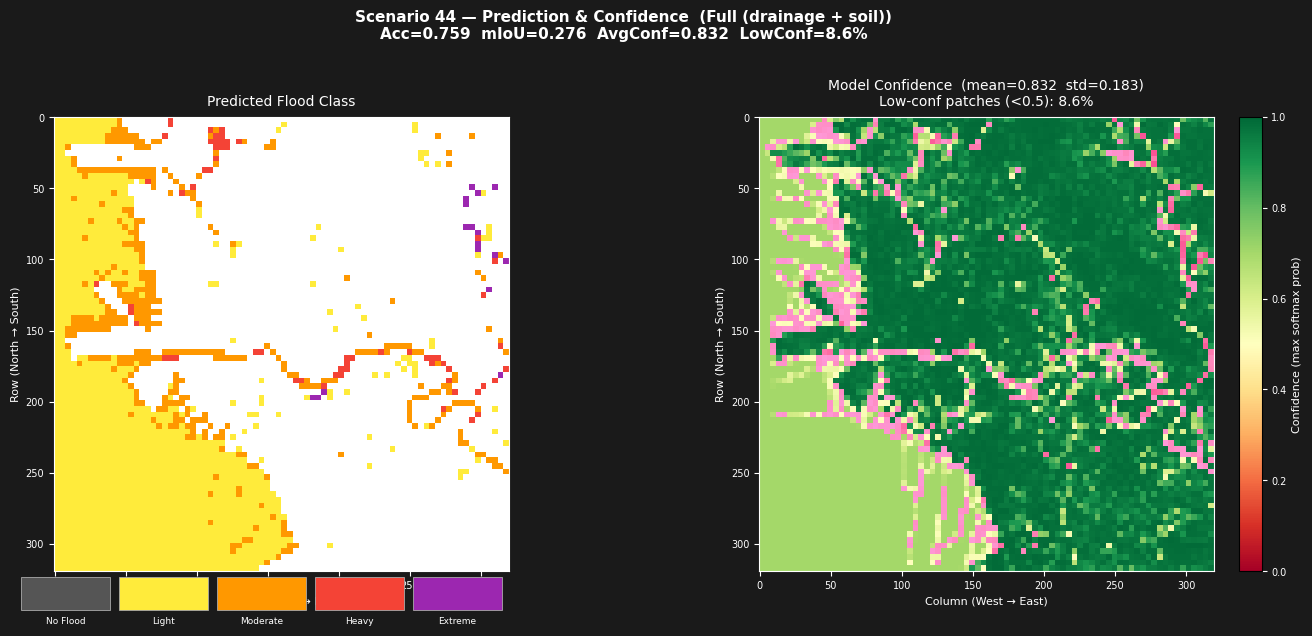

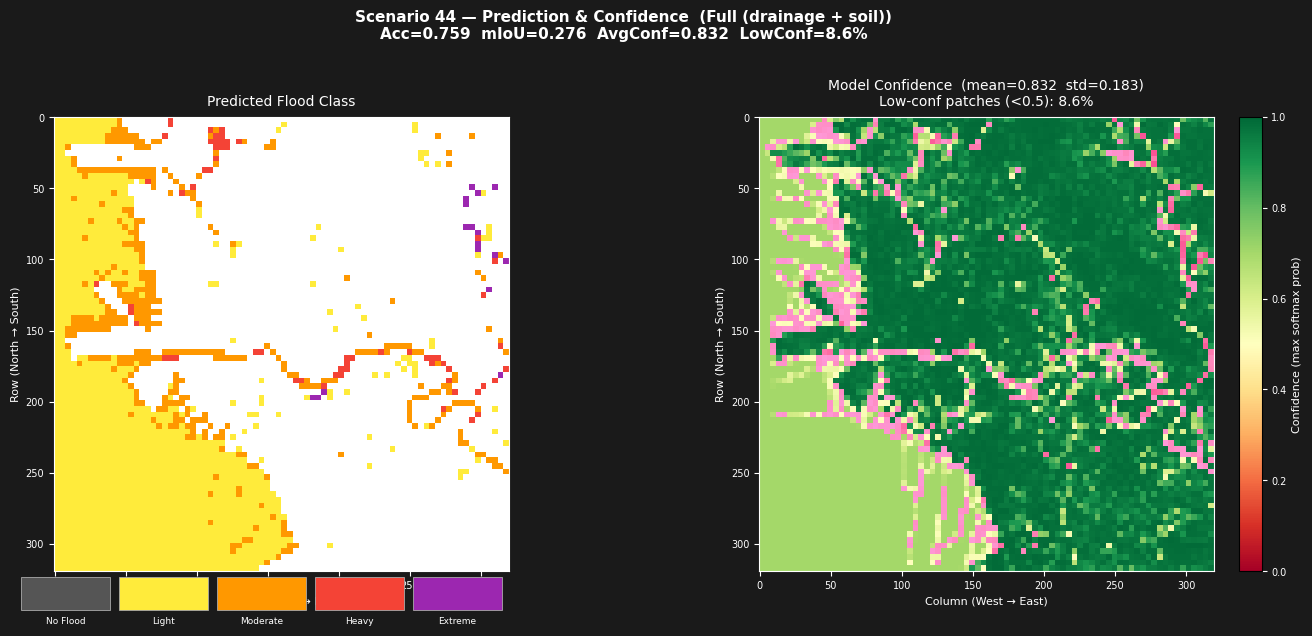

In [57]:
from testing import plot_confidence_map
plot_confidence_map(
    confidence_map = all_confidences['Full (drainage + soil)'][scenario_id],
    predicted_map  = all_predictions['Full (drainage + soil)'][scenario_id],
    scenario_id    = scenario_id,
    config_label   = 'Full (drainage + soil)',
    metrics        = all_results['Full (drainage + soil)'][scenario_id],
    save_path      = str(cfg.train.output_dir / 'test_results' / f'confidence_RS{scenario_id}.png'),
)

In [58]:
""" UNCOMMENT FOR VISUALIZATIONS OF TEST MAPS 
results_dir = Path('./results')
results_dir.mkdir(parents=True, exist_ok=True)
for config_key in all_results.keys():
    print(f"\n====== VISUALIZING: {config_key} ======")

    for scenario_id in test_scenario_ids:
        metrics = all_results[config_key][scenario_id]
        prediction = all_predictions[config_key][scenario_id]

        plot_confusion_matrix(
            metrics=metrics,
            scenario_id=scenario_id,
            save_path=results_dir / f'{config_key}_cm_scenario_{scenario_id}.png'
        )

        fig_pred = plot_flood_on_dem(
            dem=dem_normalized,
            flood_map=prediction,
            scenario_id=scenario_id,
            metrics=metrics,
            mode='pred',
            figsize=(18, 12),
            inset_center=(160, 240),
            inset_size=30
        )
"""

' UNCOMMENT FOR VISUALIZATIONS OF TEST MAPS \nresults_dir = Path(\'./results\')\nresults_dir.mkdir(parents=True, exist_ok=True)\nfor config_key in all_results.keys():\n    print(f"\n====== VISUALIZING: {config_key} ======")\n\n    for scenario_id in test_scenario_ids:\n        metrics = all_results[config_key][scenario_id]\n        prediction = all_predictions[config_key][scenario_id]\n\n        plot_confusion_matrix(\n            metrics=metrics,\n            scenario_id=scenario_id,\n            save_path=results_dir / f\'{config_key}_cm_scenario_{scenario_id}.png\'\n        )\n\n        fig_pred = plot_flood_on_dem(\n            dem=dem_normalized,\n            flood_map=prediction,\n            scenario_id=scenario_id,\n            metrics=metrics,\n            mode=\'pred\',\n            figsize=(18, 12),\n            inset_center=(160, 240),\n            inset_size=30\n        )\n'

# Hyperparamater Tuning

In [59]:
import torch
import torch.nn.functional as F
import numpy as np
import optuna
import pandas as pd
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from copy import deepcopy
from sklearn.metrics import f1_score
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader

def compute_loss(model_output, targets, cfg):
    if isinstance(model_output, tuple):
        logits = model_output[0]
    else:
        logits = model_output
    
    targets = targets.long()
    loss = F.cross_entropy(logits, targets, reduction='mean')
    return loss

def get_device():
    """Determine compute device."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}\n")
    return device

def objective_fast(trial, full_dataset, y_train, base_cfg, fold_val_indices, DEVICE, num_folds=2, num_epochs=2, mode='fast'):
    cfg = deepcopy(base_cfg)
    
    # ========== HYPERPARAMETER SUGGESTIONS ==========
    cfg.model.embed_dim         = trial.suggest_categorical('embed_dim', [128, 256, 512])
    cfg.model.num_heads         = trial.suggest_categorical('num_heads', [4, 8, 16])
    cfg.model.num_layers        = trial.suggest_int('num_layers', 2, 6)
    cfg.model.mlp_ratio         = trial.suggest_float('mlp_ratio', 1.0, 4.0, step=0.5)
    cfg.model.dropout           = trial.suggest_float('dropout', 0.0, 0.5, step=0.05)
    cfg.model.rainfall_hidden   = trial.suggest_categorical('rainfall_hidden', [32, 64, 128])
    
    cfg.train.lr                = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    cfg.train.weight_decay      = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    cfg.train.warmup_epochs     = trial.suggest_int('warmup_epochs', 5, 20)
    cfg.train.grad_clip_norm    = trial.suggest_float('grad_clip_norm', 0.5, 2.0, step=0.25)
    
    try:
        fold_scores = []
        trial_metrics = [] 
        
        # ========== K-FOLD CROSS-VALIDATION ==========
        for fold_idx, (train_idx, val_idx) in enumerate(fold_val_indices[:num_folds]):
            print(f"  Fold {fold_idx + 1}/{num_folds}...", end='', flush=True)
            
            # Create train and validation subsets
            train_subset = torch.utils.data.Subset(full_dataset, train_idx)
            val_subset = torch.utils.data.Subset(full_dataset, val_idx)
            
            # Create data loaders
            train_loader = DataLoader(train_subset, batch_size=cfg.train.batch_size, shuffle=True, num_workers=0, pin_memory=DEVICE.type == 'cuda')
            val_loader = DataLoader(val_subset, batch_size=cfg.train.batch_size, shuffle=False, num_workers=0, pin_memory=DEVICE.type == 'cuda')
            
            # Initialize model and optimizer
            model = make_model(cfg.data, cfg.model).to(DEVICE)
            optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.train.lr, weight_decay=cfg.train.weight_decay, betas=cfg.train.betas)
            
            # Early stopping within fold
            best_val_f1 = 0.0
            patience = 3
            no_improve = 0
            
            # ========== FOLD TRAINING LOOP ==========
            for epoch in range(num_epochs):
                
                # ---- Training Phase ----
                model.train()
                train_loss = 0.0
                
                for batch_data in train_loader:
                    X_spatial, X_rainfall, y = batch_data
                    
                    X_spatial = X_spatial.to(DEVICE)
                    X_rainfall = X_rainfall.to(DEVICE)
                    y = y.to(DEVICE).long()
                    
                    optimizer.zero_grad()
                    # Model takes 2 inputs: X_spatial and X_rainfall
                    model_output = model(X_spatial, X_rainfall)
                    loss = compute_loss(model_output, y, cfg)
                    
                    loss.backward()
                    if cfg.train.grad_clip_norm > 0:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.train.grad_clip_norm)
                    optimizer.step()
                    train_loss += loss.item()
                
                # ---- Validation Phase ----
                model.eval()
                val_preds = []
                val_targets = []
                
                with torch.no_grad():
                    for batch_data in val_loader:
                        # Dataset returns: X_spatial, X_rainfall, y (3 elements)
                        X_spatial, X_rainfall, y = batch_data
                        
                        X_spatial = X_spatial.to(DEVICE)
                        X_rainfall = X_rainfall.to(DEVICE)
                        
                        # Model takes 2 inputs
                        model_output = model(X_spatial, X_rainfall)
                        logits = model_output[0] if isinstance(model_output, tuple) else model_output
                        
                        preds = torch.argmax(logits, dim=1).cpu().numpy()
                        val_preds.append(preds)
                        val_targets.append(y.cpu().numpy())
                
                val_preds = np.concatenate(val_preds)
                val_targets = np.concatenate(val_targets)
                val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)
                
                # Early stopping
                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    no_improve = 0
                else:
                    no_improve += 1
                
                if no_improve >= patience:
                    break
                
                # ========== TRIAL PRUNING ==========
                # Report intermediate result to Optuna
                trial.report(val_f1, step=fold_idx * num_epochs + epoch)
                
                # Optuna prunes if trial is clearly underperforming
                if trial.should_prune():
                    print(f" [PRUNED]")
                    raise optuna.TrialPruned()
            
            fold_scores.append(best_val_f1)
            trial_metrics.append({
                'fold': fold_idx,
                'f1': best_val_f1,
                'train_loss': train_loss / len(train_loader)
            })
            print(f" F1={best_val_f1:.4f}")
        
        # Return mean F1 across all folds
        mean_f1 = np.mean(fold_scores)
        print(f"  → Trial mean F1: {mean_f1:.4f}")
        return mean_f1
        
    except optuna.TrialPruned:
        print(f" [PRUNED by Optuna]")
        raise
    except Exception as e:
        print(f"\n  ✗ Trial failed: {str(e)}")
        import traceback
        traceback.print_exc()
        return 0.0

def run_hyperparameter_tuning(train_pytorch_dataset, y_train, cfg, base_cfg,  n_trials=20, mode='fast', num_folds=2, num_epochs=2):
    DEVICE = get_device()
    RANDOM_SEED = 42

    # Prepare k-fold indices
    kfold = KFold(n_splits=cfg.train.num_folds, shuffle=True, random_state=RANDOM_SEED)
    fold_val_indices = list(kfold.split(y_train))
    
    # Configure Optuna
    sampler = TPESampler(seed=RANDOM_SEED)
    pruner = MedianPruner(n_startup_trials=3, n_warmup_steps=2)
    
    study = optuna.create_study(
        direction='maximize',
        sampler=sampler,
        pruner=pruner,
        study_name=f'optuna_tune_{mode}'
    )
    
    print(f"\n{'='*70}")
    print(f"HYPERPARAMETER TUNING: {mode.upper()} MODE")
    print(f"{'='*70}")
    print(f"Trials: {n_trials}")
    print(f"K-folds: {num_folds} (per trial)")
    print(f"Epochs: {num_epochs} (per fold)")
    print(f"Estimated time: {n_trials * num_folds * num_epochs * 2} min")
    print(f"{'='*70}\n")
    
    # Run optimization
    study.optimize(
        lambda trial: objective_fast(
            trial, 
            train_pytorch_dataset, 
            y_train, 
            base_cfg, 
            fold_val_indices, 
            DEVICE,
            num_folds=num_folds,
            num_epochs=num_epochs,
            mode=mode
        ),
        n_trials=n_trials,
        show_progress_bar=True
    )
    
    # Print results
    print(f"\n{'='*70}")
    print("OPTIMIZATION RESULTS")
    print(f"{'='*70}")
    print(f"Best F1 Score: {study.best_value:.4f}")
    print(f"Best Trial: {study.best_trial.number}")
    print(f"\nBest Hyperparameters:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")
    print(f"{'='*70}\n")
    
    return study

def get_best_config(study, base_cfg):
    cfg = deepcopy(base_cfg)
    
    # Apply best hyperparameters to config
    best_params = study.best_params
    cfg.model.embed_dim = best_params['embed_dim']
    cfg.model.num_heads = best_params['num_heads']
    cfg.model.num_layers = best_params['num_layers']
    cfg.model.mlp_ratio = best_params['mlp_ratio']
    cfg.model.dropout = best_params['dropout']
    cfg.model.rainfall_hidden = best_params['rainfall_hidden']
    
    cfg.train.lr = best_params['lr']
    cfg.train.weight_decay = best_params['weight_decay']
    cfg.train.warmup_epochs = best_params['warmup_epochs']
    cfg.train.grad_clip_norm = best_params['grad_clip_norm']
    
    return cfg

c:\Users\CENSER\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [60]:
import torch
import json
import pandas as pd
import numpy as np
from copy import deepcopy
from sklearn.model_selection import train_test_split
from model_config import make_model

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# ========== EXTRACT LABELS ==========
print("\n" + "="*70)
print(" DATA PREPARATION")
print("="*70)

print("\nExtracting labels from full dataset...", end='', flush=True)
y_full = []
for i in range(len(train_pytorch_dataset)):
    sample = train_pytorch_dataset[i]
    label = sample[2]
    if isinstance(label, torch.Tensor):
        label = label.item() if label.ndim == 0 else label.argmax().item()
    y_full.append(label)
y_full = np.array(y_full)
print(f" ✓ {len(y_full)} labels extracted")
print(f"  Class distribution: {np.bincount(y_full)}")

# Create subset for fast tuning
print("\nCreating stratified subset for hyperparameter tuning...")
subset_size = 0.5  # Use 50% of data for tuning
tune_indices, _ = train_test_split(
    np.arange(len(y_full)), 
    test_size=1-subset_size, 
    stratify=y_full, 
    random_state=42
)
tune_dataset = torch.utils.data.Subset(train_pytorch_dataset, tune_indices)
y_train = y_full[tune_indices]  
print(f"  Tuning set size: {len(y_train)} samples")
print(f"  Class distribution: {np.bincount(y_train)}\n")

# ========== HYPERPARAMETER TUNING ==========
print("="*70)
print("HYPERPARAMETER TUNING (on subset)")
print("="*70)

base_cfg = deepcopy(cfg)
base_cfg.RANDOM_SEED = 42 

study_fast = run_hyperparameter_tuning(
    train_pytorch_dataset   = tune_dataset,  
    y_train                 = y_train,                     
    cfg                     = cfg,
    base_cfg                = base_cfg,
    n_trials                = 20,
    mode                    = 'fast',
    num_folds               = cfg.train.num_folds,
    num_epochs              = cfg.train.num_epochs
)

print("\nBest hyperparameters (from fast tuning):")
for key, value in study_fast.best_params.items():
    print(f"  {key}: {value}")

# ========== SAVE HYPERPARAMETER RESULTS ==========
print("\n" + "="*70)
print("SAVING HYPERPARAMETER TUNING RESULTS")
print("="*70)

# Create logs directory
logs_dir = cfg.train.output_dir / 'logs'
logs_dir.mkdir(parents=True, exist_ok=True)

# Create best params dictionary
best_params_dict = {
    **study_fast.best_params,
    'best_f1': float(study_fast.best_value),
    'best_trial': int(study_fast.best_trial.number),
    'total_trials': len(study_fast.trials)
}

# Save to JSON
best_params_json = logs_dir / 'best_hyperparams.json'
with open(best_params_json, 'w') as f:
    json.dump(best_params_dict, f, indent=2)
print(f"✓ Saved best hyperparameters to JSON:")
print(f"  {best_params_json}")

# Save all trials to JSON
all_trials_json = logs_dir / 'all_trials.json'
all_trials_dict = {
    'num_trials': len(study_fast.trials),
    'trials': []
}

for trial in study_fast.trials:
    trial_dict = {
        'number': trial.number,
        'state': str(trial.state),
        'value': float(trial.value) if trial.value is not None else None,
        'params': trial.params,
    }
    all_trials_dict['trials'].append(trial_dict)

with open(all_trials_json, 'w') as f:
    json.dump(all_trials_dict, f, indent=2)
print(f"✓ Saved all {len(study_fast.trials)} trial results to JSON:")
print(f"  {all_trials_json}")

# ========== APPLY BEST HYPERPARAMETERS ==========
print("\n" + "="*70)
print("APPLYING BEST HYPERPARAMETERS TO CONFIG")
print("="*70)

final_cfg = deepcopy(cfg)

# Apply to model config
final_cfg.model.embed_dim = study_fast.best_params['embed_dim']
final_cfg.model.num_heads = study_fast.best_params['num_heads']
final_cfg.model.num_layers = study_fast.best_params['num_layers']
final_cfg.model.mlp_ratio = study_fast.best_params['mlp_ratio']
final_cfg.model.dropout = study_fast.best_params['dropout']
final_cfg.model.rainfall_hidden = study_fast.best_params['rainfall_hidden']

# Apply to training config
final_cfg.train.lr = study_fast.best_params['lr']
final_cfg.train.weight_decay = study_fast.best_params['weight_decay']
final_cfg.train.warmup_epochs = study_fast.best_params['warmup_epochs']
final_cfg.train.grad_clip_norm = study_fast.best_params['grad_clip_norm']

print("\n✓ Config updated with best hyperparameters:")
print(f"  embed_dim: {final_cfg.model.embed_dim}")
print(f"  num_heads: {final_cfg.model.num_heads}")
print(f"  num_layers: {final_cfg.model.num_layers}")
print(f"  mlp_ratio: {final_cfg.model.mlp_ratio}")
print(f"  dropout: {final_cfg.model.dropout}")
print(f"  rainfall_hidden: {final_cfg.model.rainfall_hidden}")
print(f"  lr: {final_cfg.train.lr}")
print(f"  weight_decay: {final_cfg.train.weight_decay}")
print(f"  warmup_epochs: {final_cfg.train.warmup_epochs}")
print(f"  grad_clip_norm: {final_cfg.train.grad_clip_norm}")

# Save updated config to JSON
config_json = logs_dir / 'config_with_best_hyperparams.json'
final_cfg.save(config_json)
print(f"\n✓ Saved updated config to:")
print(f"  {config_json}")


Device: cuda

 DATA PREPARATION

Extracting labels from full dataset...

[I 2026-03-07 19:49:14,916] A new study created in memory with name: optuna_tune_fast


 ✓ 224000 labels extracted
  Class distribution: [160957   7124  12346   7253  36320]

Creating stratified subset for hyperparameter tuning...
  Tuning set size: 112000 samples
  Class distribution: [80479  3562  6173  3626 18160]

HYPERPARAMETER TUNING (on subset)
Device: cuda


HYPERPARAMETER TUNING: FAST MODE
Trials: 10
K-folds: 2 (per trial)
Epochs: 20 (per fold)
Estimated time: 800 min



  0%|          | 0/10 [00:00<?, ?it/s]

  Fold 1/2... F1=0.4565
  Fold 2/2...

...

 [PRUNED]
 [PRUNED by Optuna]
[I 2026-03-07 20:01:30,574] Trial 7 pruned. 
  Fold 1/2... F1=0.4330
  Fold 2/2...

Best trial: 2. Best value: 0.457283:  90%|█████████ | 9/10 [15:18<01:31, 91.07s/it]

 F1=0.4513
  → Trial mean F1: 0.4422
[I 2026-03-07 20:04:33,861] Trial 8 finished with value: 0.44216321249581614 and parameters: {'embed_dim': 256, 'num_heads': 16, 'num_layers': 6, 'mlp_ratio': 2.0, 'dropout': 0.25, 'rainfall_hidden': 128, 'lr': 0.0008411909465645721, 'weight_decay': 3.188339735100187e-05, 'warmup_epochs': 12, 'grad_clip_norm': 1.0}. Best is trial 2 with value: 0.4572832772728602.
  Fold 1/2... F1=0.4405
  Fold 2/2...

Best trial: 2. Best value: 0.457283: 100%|██████████| 10/10 [18:27<00:00, 110.75s/it]

 F1=0.4517
  → Trial mean F1: 0.4461
[I 2026-03-07 20:07:42,394] Trial 9 finished with value: 0.44609213231083844 and parameters: {'embed_dim': 512, 'num_heads': 4, 'num_layers': 6, 'mlp_ratio': 1.5, 'dropout': 0.05, 'rainfall_hidden': 64, 'lr': 0.00022093834415066264, 'weight_decay': 0.00033361013094697806, 'warmup_epochs': 8, 'grad_clip_norm': 1.75}. Best is trial 2 with value: 0.4572832772728602.

OPTIMIZATION RESULTS
Best F1 Score: 0.4573
Best Trial: 2

Best Hyperparameters:
  embed_dim: 512
  num_heads: 4
  num_layers: 5
  mlp_ratio: 2.5
  dropout: 0.05
  rainfall_hidden: 128
  lr: 3.292759134423613e-05
  weight_decay: 0.00021137059440645722
  warmup_epochs: 9
  grad_clip_norm: 1.25


Best hyperparameters (from fast tuning):
  embed_dim: 512
  num_heads: 4
  num_layers: 5
  mlp_ratio: 2.5
  dropout: 0.05
  rainfall_hidden: 128
  lr: 3.292759134423613e-05
  weight_decay: 0.00021137059440645722
  warmup_epochs: 9
  grad_clip_norm: 1.25

SAVING HYPERPARAMETER TUNING RESULTS
✓ Saved b

In [61]:
print("\n" + "="*70)
print("SAVING HYPERPARAMETER TUNING RESULTS")
print("="*70)

# Create logs directory
logs_dir = cfg.train.output_dir / 'logs'
logs_dir.mkdir(parents=True, exist_ok=True)

# Create best params dictionary
best_params_dict = {
    **study_fast.best_params,
    'best_f1': float(study_fast.best_value),
    'best_trial': int(study_fast.best_trial.number),
    'total_trials': len(study_fast.trials)
}

# Save to JSON
best_params_json = logs_dir / 'best_hyperparams.json'
with open(best_params_json, 'w') as f:
    json.dump(best_params_dict, f, indent=2)
print(f"✓ Saved best hyperparameters to JSON:")
print(f"  {best_params_json}")

# Save all trials to JSON
all_trials_json = logs_dir / 'all_trials.json'
all_trials_dict = {
    'num_trials': len(study_fast.trials),
    'trials': []
}

for trial in study_fast.trials:
    trial_dict = {
        'number': trial.number,
        'state': str(trial.state),
        'value': float(trial.value) if trial.value is not None else None,
        'params': trial.params,
    }
    all_trials_dict['trials'].append(trial_dict)

with open(all_trials_json, 'w') as f:
    json.dump(all_trials_dict, f, indent=2)
print(f"✓ Saved all {len(study_fast.trials)} trial results to JSON:")
print(f"  {all_trials_json}")


SAVING HYPERPARAMETER TUNING RESULTS
✓ Saved best hyperparameters to JSON:
  checkpoints\logs\best_hyperparams.json
✓ Saved all 10 trial results to JSON:
  checkpoints\logs\all_trials.json


In [62]:
print("\n" + "="*70)
print("FINAL TRAINING WITH BEST HYPERPARAMETERS (on full dataset)")
print("="*70)

# Apply best hyperparameters to your ORIGINAL config
final_cfg = deepcopy(cfg)
final_cfg.model.embed_dim = study_fast.best_params['embed_dim']
final_cfg.model.num_heads = study_fast.best_params['num_heads']
final_cfg.model.num_layers = study_fast.best_params['num_layers']
final_cfg.model.mlp_ratio = study_fast.best_params['mlp_ratio']
final_cfg.model.dropout = study_fast.best_params['dropout']
final_cfg.model.rainfall_hidden = study_fast.best_params['rainfall_hidden']

final_cfg.train.lr = study_fast.best_params['lr']
final_cfg.train.weight_decay = study_fast.best_params['weight_decay']
final_cfg.train.warmup_epochs = study_fast.best_params['warmup_epochs']
final_cfg.train.grad_clip_norm = study_fast.best_params['grad_clip_norm']

print(f"\nTraining final model with best hyperparameters...")
print(f"Best F1 from tuning: {study_fast.best_value:.4f}\n")

fold_histories, best_fold = train_kfold(
    model              = model_factory(final_cfg.data, final_cfg.model),
    full_dataset       = train_pytorch_dataset,
    scenario_to_samples= scenario_to_samples, 
    cfg                = final_cfg.train,
    device             = DEVICE,
    checkpoint_dir     = final_cfg.train.output_dir,
)

print(f"\n✓ Final model training complete!")
print(f"  Best fold: {best_fold + 1}")



FINAL TRAINING WITH BEST HYPERPARAMETERS (on full dataset)

Training final model with best hyperparameters...
Best F1 from tuning: 0.4573


K-FOLD CROSS-VALIDATION
Checkpoint directory: checkpoints
Fold 1: 18 train scenarios, 17 val scenarios
Fold 2: 17 train scenarios, 18 val scenarios

Fold 1: 115,200 train, 108,800 val samples

FOLD 1

Class distribution:
  Class 0: 85,403 (74.13%)  weight=0.270
  Class 1:  3,711 ( 3.22%)  weight=6.209
  Class 2:  5,859 ( 5.09%)  weight=3.932
  Class 3:  3,704 ( 3.22%)  weight=6.220
  Class 4: 16,523 (14.34%)  weight=1.394
Epoch   1/20 | LR:0.000000 | Train Loss:1.5361 Acc:0.1451 | Val Loss:1.5235 Acc:0.1759 | Val F1:0.0860
  → Best Macro F1: 0.0860
Epoch   2/20 | LR:0.000004 | Train Loss:1.4250 Acc:0.6417 | Val Loss:1.3580 Acc:0.7960 | Val F1:0.3274
  → Best Macro F1: 0.3274
Epoch   3/20 | LR:0.000007 | Train Loss:1.3562 Acc:0.7327 | Val Loss:1.3030 Acc:0.8031 | Val F1:0.4172
  → Best Macro F1: 0.4172
Epoch   4/20 | LR:0.000011 | Train Loss:1.2422

In [64]:
# ========== EVALUATE ON TEST SET ==========
print("\n" + "="*70)
print("EVALUATING ON TEST SET")
print("="*70)

print("\nLoading best model from final training...")
model_path = final_cfg.train.output_dir / f'fold_{best_fold + 1}' / 'best_model.pt'
ckpt = torch.load(model_path, map_location=DEVICE)

final_model = make_model(final_cfg.data, final_cfg.model)
final_model.load_state_dict(ckpt['model_state_dict'])
final_model.to(DEVICE)
final_model.eval()

print(f"✓ Loaded model from Fold {best_fold + 1}")
print(f"  Best macro F1 (validation): {ckpt['best_macro_f1']:.4f}")

all_results, all_predictions, all_confidences = evaluate_test_scenarios(
    model              = final_model,
    patch_size         = final_cfg.data.patch_size,
    test_dataset_dict  = test_dataset,
    FloodPatchDataset  = FloodPatchDataset,
    test_scenario_ids  = test_scenario_ids,
    ground_truth_maps  = ground_truth_maps,
    device             = DEVICE,
    save_dir           = final_cfg.train.output_dir / 'test_results',
)

print(f"\n✓ Evaluation complete!")
print(f"  Results saved to: {final_cfg.train.output_dir / 'test_results'}")



EVALUATING ON TEST SET

Loading best model from final training...
✓ Loaded model from Fold 1
  Best macro F1 (validation): 0.5098

EVALUATING — Full (drainage + soil)
  hasDrainage=True  |  hasSoil=True
FloodPatchDataset initialized:
  Mode                 : EVAL/INFERENCE (fixed masking)
  Total samples        : 96,000
  Scenarios            : 15
  Patches per scenario : 6400
  Spatial patch shape  : (11, 4, 4)
  Conditioning dim     : (21,)
  tpeak range          : [0.000, 0.000]
  depth_norm range     : [0.000, 0.000]
  hasDrainage          : True
  hasSoil              : True

  [Scenario 1] Predicting...
  [Scenario 1]  Acc=0.6805  mIoU=0.2648  AvgConf=0.7115  LowConf=32.2%

  [Scenario 4] Predicting...
  [Scenario 4]  Acc=0.6434  mIoU=0.2234  AvgConf=0.6559  LowConf=38.8%

  [Scenario 10] Predicting...
  [Scenario 10]  Acc=0.7278  mIoU=0.3032  AvgConf=0.7014  LowConf=33.2%

  [Scenario 11] Predicting...
  [Scenario 11]  Acc=0.7181  mIoU=0.2561  AvgConf=0.7350  LowConf=27.5%

  [

In [63]:
# ========== UPDATE INFERENCE CONFIG ==========
print("\n" + "="*70)
print("UPDATING INFERENCE CONFIG FOR INFERENCE PIPELINE")
print("="*70)

print("\nLoading old inference config...")
old_inference_config_path = final_cfg.train.output_dir / 'inference_config.json'

if old_inference_config_path.exists():
    with open(old_inference_config_path, 'r') as f:
        old_inference_config = json.load(f)
    
    print(f"✓ Loaded old config")
    print(f"  Old best_fold: {old_inference_config.get('best_fold', 'N/A')}")
    
    # Create updated inference config with best fold and ALL hyperparameters
    new_inference_config = {
        # Keep data configuration unchanged
        'rain_min'        : old_inference_config['rain_min'],
        'rain_max'        : old_inference_config['rain_max'],
        'patch_size'      : old_inference_config['patch_size'],
        'num_classes'     : old_inference_config['num_classes'],
        'input_channels'  : old_inference_config['input_channels'],
        'conditioning_dim': old_inference_config['conditioning_dim'],
        'drain_channels'  : old_inference_config['drain_channels'],
        'soil_channels'   : old_inference_config['soil_channels'],
        'depth_min'       : old_inference_config['depth_min'],
        'depth_max'       : old_inference_config['depth_max'],
        'n_steps'         : old_inference_config['n_steps'],
        'n_real'          : old_inference_config['n_real'],
        'dt_min'          : old_inference_config['dt_min'],
        'duration_hr'     : old_inference_config['duration_hr'],
        
        # ========== UPDATE: NEW BEST FOLD ==========
        'best_fold'       : best_fold + 1,
        
        # ========== UPDATE: MODEL HYPERPARAMETERS FROM TUNING ==========
        'embed_dim'       : study_fast.best_params['embed_dim'],
        'num_heads'       : study_fast.best_params['num_heads'],
        'num_layers'      : study_fast.best_params['num_layers'],
        'mlp_ratio'       : study_fast.best_params['mlp_ratio'],
        'dropout'         : study_fast.best_params['dropout'],
        'rainfall_hidden' : study_fast.best_params['rainfall_hidden'],
        
        # ========== UPDATE: TRAINING HYPERPARAMETERS FROM TUNING ==========
        'lr'              : study_fast.best_params['lr'],
        'weight_decay'    : study_fast.best_params['weight_decay'],
        'warmup_epochs'   : study_fast.best_params['warmup_epochs'],
        'grad_clip_norm'  : study_fast.best_params['grad_clip_norm'],
        
        # ========== UPDATE: TUNING METADATA ==========
        'best_trial'      : study_fast.best_trial.number,
        'total_trials'    : len(study_fast.trials),
        'tuning_best_f1'  : float(study_fast.best_value),
        'validation_f1'   : float(ckpt['best_macro_f1']),
    }
    
    # Save updated inference config
    with open(old_inference_config_path, 'w') as f:
        json.dump(new_inference_config, f, indent=2)


UPDATING INFERENCE CONFIG FOR INFERENCE PIPELINE

Loading old inference config...
✓ Loaded old config
  Old best_fold: 1
